In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
import pandas as pd
import warnings
def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax

# Suppress warnings
warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [2]:
def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]

def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]

def set_cmp(a,b, vals=False):
    return (set_diff(a,b,vals), set_itx(a,b,vals), set_diff(b,a,vals))

In [3]:
datasets = [
    "adipose_Emont2022",
    "adipose_Hildreth2021",
    "bone_He2021",
    "eye_Gautam2021",
    "lung_Adams2020",
    "ovary_Wagner2020",
    "testis_Shamis2020",
]
degs  = []
exts = []
llms = []
for dataset in datasets:
    ds_name = datasets[3]

    ext = pd.read_json(f"../data/{dataset}/evidence_human/extracted.json").assign(ds_name=dataset)
    
    # Drop rows where 'group_name' is missing, since some cell types lack DEGs
    ext = ext.dropna(subset=["group_name"])
    
    exts.append(ext)
    
    deg = pd.read_json(f"../data/{dataset}/evidence_deg/extracted.json").assign(ds_name=dataset)
    degs.append(deg)
    
    llm = pd.read_json(f"../data/{dataset}/evidence_llm/extracted_txt.json").assign(ds_name=dataset)
    llms.append(llm)

deg = pd.concat(degs)

print("DEG gene names without an Ensembl ID")
print(deg[deg["feature_id"].isna()].groupby("ds_name")["feature_name"].nunique())
deg = deg.dropna(subset="feature_id")

ext = pd.concat(exts).drop_duplicates(subset=["ds_name", "data_id", "source_type", "group_name", "feature_id"])
llm = pd.concat(llms)

DEG gene names without an Ensembl ID
ds_name
adipose_Emont2022       870
adipose_Hildreth2021    302
bone_He2021              50
eye_Gautam2021          524
lung_Adams2020           86
ovary_Wagner2020        310
testis_Shamis2020       267
Name: feature_name, dtype: int64


In [4]:
ext["source_type"].value_counts()

source_type
image    1561
text      426
Name: count, dtype: int64

In [5]:
deg.shape

(224084, 15)

In [6]:
deg.groupby(["ds_name", "data_id", "source_type", "group_name"])["feature_id"].apply(lambda x: len(x) - np.unique(x).shape[0]).sum()

np.int64(244)

In [7]:
txtidx = ext.query("source_type == 'text'").set_index(["ds_name", "data_id", "group_name", "feature_id"])
imgidx = ext.query("source_type == 'image'").set_index(["ds_name", "data_id", "group_name", "feature_id"])
degidx = deg.set_index(["ds_name", "data_id", "group_name", "feature_id"])

commtxt = txtidx.index.intersection(degidx.index)
txtidx = txtidx.loc[commtxt].copy()

commimg = imgidx.index.intersection(degidx.index)
imgidx = imgidx.loc[commimg].copy()

txtidx[["metrics_pcorr", "metrics_logfc", "metrics_rank"]] = degidx.loc[commtxt][["metrics_pcorr", "metrics_logfc", "metrics_rank"]].values

imgidx[["metrics_pcorr", "metrics_logfc", "metrics_rank"]] = degidx.loc[commimg][["metrics_pcorr", "metrics_logfc", "metrics_rank"]].values

In [8]:
ext = pd.concat([txtidx.reset_index(), imgidx.reset_index()])

In [9]:
t2 = deg.groupby("data_id")["group_name"].unique()
t1 = ext.groupby("data_id")["group_name"].unique()

ext[ext['group_name'].isna()]
deg[deg.group_name.isna()]
t1.combine(t2, lambda a, b: np.setdiff1d(a, b)).rename("ext")

data_id
ALL-Supplementary_Data_S6-aba1983_data_s6                              []
ALL_COPD_CTRL-Supplementary_Data_S9-aba1983_data_s9                 [nan]
ALL_IPF_COPD-Supplementary_Data_S10-aba1983_data_s10                [nan]
ALL_IPF_CTRL-Supplementary_Data_S8-aba1983_data_s8                  [nan]
EPITHELIAL-Supplementary_Data_S2-aba1983_data_s2                       []
LYMPHOID-Supplementary_Data_S5-aba1983_data_s5                      [nan]
MYELOID-Supplementary_Data_S4-aba1983_data_s4                       [nan]
STROMAL-Supplementary_Data_S3-aba1983_data_s3                          []
Supplementary Dataset 1#Variable genes clusters                        []
Supplementary Dataset 2#Variable genes Orig.Ident                      []
Supplementary Dataset 2#Variable genes clusters                        []
Supplementary Table 1#ASPC markers                                     []
Supplementary Table 1#Cluster_Markers_CD45PosNeg                       []
Supplementary Table 1#Cluster_

In [10]:
etmp = ext.query("ds_name == 'adipose_Emont2022'").set_index(["group_name", "feature_id", "data_id"])
dtmp = deg.query("ds_name == 'adipose_Emont2022'").set_index(["group_name", "feature_id", "data_id"])

In [11]:
comm = etmp.index.intersection(dtmp.index)
# dtmp.loc[comm].reset_index().groupby(["data_id", "group_name"])["metrics_rank"].agg(["min"])

In [12]:
def cmp_lfc(df, deg, n_top=75, ds_name="", ct_col="group_name", ft_col="feature_id"):
    
    def process_modality(mod_df):
        mod_name = mod_df['source_type'].iloc[0]
        
        # Get indices for this modality
        mod_idx = mod_df.set_index([ct_col, ft_col, "data_id"]).index
        deg_idx = deg.set_index([ct_col, ft_col, "data_id"]).index
        
        # Compute intersections and differences
        comm_idx = deg_idx.intersection(mod_idx)
        setd_idx = deg_idx.difference(mod_idx)
        
        # Discussed entries (intersection)
        discussed = (deg
                    .set_index([ct_col, ft_col, "data_id"])
                    .loc[comm_idx]
                    .reset_index()
                    [[ct_col, ft_col, "feature_name", "metrics_pcorr", "metrics_logfc", "metrics_rank", "data_id"]]
                    .assign(modality=mod_name, discussed=True))
        
        # Get unique cell types and gene counts for this modality
        ct_list = discussed[ct_col].unique()
        ng_per_ct = discussed.groupby(["data_id", ct_col])[ft_col].apply(lambda x: len(x.unique()))
        # ng_per_ct = deg.set_index([ct_col, ft_col, "data_id"]).loc[setd_idx].groupby(ct_col)[ft_col].apply(lambda x: len(x.unique()))
        
        # Not discussed entries (sampled from difference)
        nd_pool = (deg
                  .set_index([ct_col, ft_col, "data_id"])
                  .loc[setd_idx]
                  .reset_index()
                  .query("metrics_pcorr < 0.05"))
        
        nd_parts = []
        for (did, ct), grp in nd_pool.groupby(["data_id", ct_col]):
            n_sample = min(n_top, ng_per_ct.get((did, ct), 0))
            if n_sample == 0:
                continue
            top = grp.nlargest(int(n_top), "metrics_logfc")
            sampled = top.sample(n=min(n_sample, len(top)), random_state=42)
            nd_parts.append(sampled)
        
        if nd_parts:
            not_discussed = (pd.concat(nd_parts)
                            [[ct_col, ft_col, "feature_name", "metrics_pcorr", "metrics_logfc", "metrics_rank", "data_id"]]
                            .assign(modality=mod_name, discussed=False))
        else:
            not_discussed = pd.DataFrame(columns=[ct_col, ft_col, "feature_name", "metrics_pcorr", "metrics_logfc", "metrics_rank", "data_id", "modality", "discussed"])
        
        return pd.concat([discussed, not_discussed])
    
    # Process each modality and combine results
    result = pd.concat([process_modality(grp) for _, grp in df.groupby('source_type')])
    result = result.reset_index(drop=True).assign(dataset=ds_name, n_top=n_top)
    
    return result

def compare_rank_distributions(ranks_a, ranks_b, method="mannwhitney", 
                              n_permutations=10000, alternative="two-sided", stat="median"):
    """
    Compare rank distributions between two groups.
    
    Parameters:
        ranks_a, ranks_b: Arrays of ranks to compare
        method: "mannwhitney" or "permutation"
        n_permutations: Number of permutations for permutation test
        alternative: 'two-sided', 'less', 'greater'
        stat: 'mean' or 'median' (for permutation test)
    
    Returns:
        p-value (float)
    """
    if method == "mannwhitney":
        return mannwhitneyu(ranks_a, ranks_b, alternative=alternative).pvalue

    elif method == "permutation":
        # Calculate observed statistic
        if stat == "mean":
            observed = np.mean(ranks_a)
        elif stat == "median":
            observed = np.median(ranks_a)
        else:
            raise ValueError("stat must be 'mean' or 'median'")

        # Combine both groups for permutation
        combined = np.concatenate([ranks_a, ranks_b])
        n_a = len(ranks_a)

        # Generate permuted statistics
        permuted_stats = np.array([
            (np.median if stat == "median" else np.mean)(
                np.random.choice(combined, size=n_a, replace=False)
            )
            for _ in range(n_permutations)
        ])

        # Calculate p-value based on alternative hypothesis
        if alternative == "less":
            p_val = (np.sum(permuted_stats <= observed) + 1) / (n_permutations + 1)
        elif alternative == "greater":
            p_val = (np.sum(permuted_stats >= observed) + 1) / (n_permutations + 1)
        else:  # two-sided
            center = np.median(combined) if stat == "median" else np.mean(combined)
            obs_diff = np.abs(observed - center)
            perm_diff = np.abs(permuted_stats - center)
            p_val = (np.sum(perm_diff >= obs_diff) + 1) / (n_permutations + 1)

        return p_val
    else:
        raise ValueError("method must be 'mannwhitney' or 'permutation'")

def compare_ranks(group):
    """Compare discussed vs not-discussed ranks for a single cell-type/modality group"""
    discussed_mask = group.index.get_level_values("discussed") == True
    not_discussed_mask = group.index.get_level_values("discussed") == False
    
    # Ensure both groups exist
    if discussed_mask.any() and not_discussed_mask.any():
        discussed_ranks = group.loc[discussed_mask].values[0]
        not_discussed_ranks = group.loc[not_discussed_mask].values[0]
        
        # Test if discussed ranks are significantly lower (stronger markers)
        p_val = compare_rank_distributions(
            discussed_ranks, not_discussed_ranks,
            method="permutation",
            stat="mean", 
            alternative="two-sided"  # Test if discussed < not_discussed (stronger)
        )
        return p_val
    else:
        return None

def analyze_marker_strength(df):
    test = (
        df.groupby(["dataset", "data_id", "modality", "group_name", "discussed"])["metrics_rank"]
        .agg(["mean", "median", "var", "std", "count"])  # Added median and std
        .unstack("discussed")
        .pipe(lambda df: df.set_axis(
            df.columns.set_levels(
                ["not discussed" if val is False else "discussed" for val in df.columns.levels[1]],
                level=1
            ),
            axis=1
        ))
        .swaplevel(axis=1)
        .sort_index(axis=1)
    )
    # Apply over the grouped data (keeping your exact format)
    pvals = (
        df.groupby(["dataset", "data_id", "modality", "group_name", "discussed"])["metrics_rank"]
        .apply(list)
        .groupby(["dataset", "data_id", "modality", "group_name"])
        .apply(compare_ranks)
    ).to_frame()

    pvals.columns = pd.MultiIndex.from_tuples([("permutation_pval", "")])


    # Calculate differences and effect size
    test = test.assign(
        # difference=test[("discussed", "mean")] - test[("not discussed", "mean")],
        mean_difference=test[("discussed", "mean")] - test[("not discussed", "mean")],
        median_difference=test[("discussed", "median")] - test[("not discussed", "median")],
        effect_size=lambda x: (x[("discussed", "mean")] - x[("not discussed", "mean")]) / np.sqrt(
            (x[("discussed", "std")]**2 + x[("not discussed", "std")]**2) / 2
        )
    )

    pvals = pvals.reindex(test.index)

    test = pd.concat([test, pvals], axis=1).assign(significant=lambda x: x["permutation_pval"] < 0.05)

    test = test.copy()
    for col in ["discussed", "not discussed"]:
        for stat in ["mean", "std", "var"]:
            test[(col, stat)] = test[(col, stat)].astype(float).round(0).astype("Int64")

    test["mean_difference"] = test["mean_difference"].astype(float).round(0).astype("Int64")
    test["median_difference"] = test["median_difference"].astype(float).round(0).astype("Int64")

    return test


In [13]:
data = pd.concat([cmp_lfc(ext.query(f"ds_name == '{dataset}'"), deg.query(f"ds_name == '{dataset}'"), n_top=100, ds_name=dataset) for dataset in datasets])

In [14]:
np.random.seed(42)
test = analyze_marker_strength(data)
test = test.dropna(subset=[("permutation_pval", "")]).dropna(subset=[("effect_size", "")])

In [15]:
test

discussed  \
                                                                                                             count   
dataset           data_id                                    modality group_name                                     
adipose_Emont2022 Supplementary Table 1#ASPC markers         image    ADIPOSE STEM AND PROGENITOR CELL 1         2   
                  Supplementary Table 1#adipocyte markers    image    ADIPOCYTE 1                               11   
                                                                      ADIPOCYTE 2                                7   
                                                                      ADIPOCYTE 3                                6   
                                                                      ADIPOCYTE 4                               15   
...                                                                                                            ...   
testis_Shamis2020 Supplementary Table S6#B.HumanSoma-Markers text     IMMATURE LEYDIG CELL                       5   
                                                                      M-PERICYTE                                 8   
                                                                      MACROPHAGE                                 4   
                                                                      MYOID CELL                                 3   
                                                                      T CELL                                     5   

                                                                                                               \
                                                                                                         mean   
dataset           data_id                                    modality group_name                                
adipose_Emont2022 Supplementary Table 1#ASPC markers         image    ADIPOSE STEM AND PROGENITOR CELL 1  237   
                  Supplementary Table 1#adipocyte markers    image    ADIPOCYTE 1                         141   
                                                                      ADIPOCYTE 2                         111   
                                                                      ADIPOCYTE 3                          85   
                                                                      ADIPOCYTE 4                         138   
...                                                                                                       ...   
testis_Shamis2020 Supplementary Table S6#B.HumanSoma-Markers text     IMMATURE LEYDIG CELL                 79   
                                                                      M-PERICYTE                           62   
                                                                      MACROPHAGE                           40   
                                                                      MYOID CELL                          170   
                                                                      T CELL                               52   

                                                                                                                 \
                                                                                                         median   
dataset           data_id                                    modality group_name                                  
adipose_Emont2022 Supplementary Table 1#ASPC markers         image    ADIPOSE STEM AND PROGENITOR CELL 1  237.0   
                  Supplementary Table 1#adipocyte markers    image    ADIPOCYTE 1                          94.0   
                                                                      ADIPOCYTE 2                         125.0   
                                                                      ADIPOCYTE 3                          58.0   
                                                                

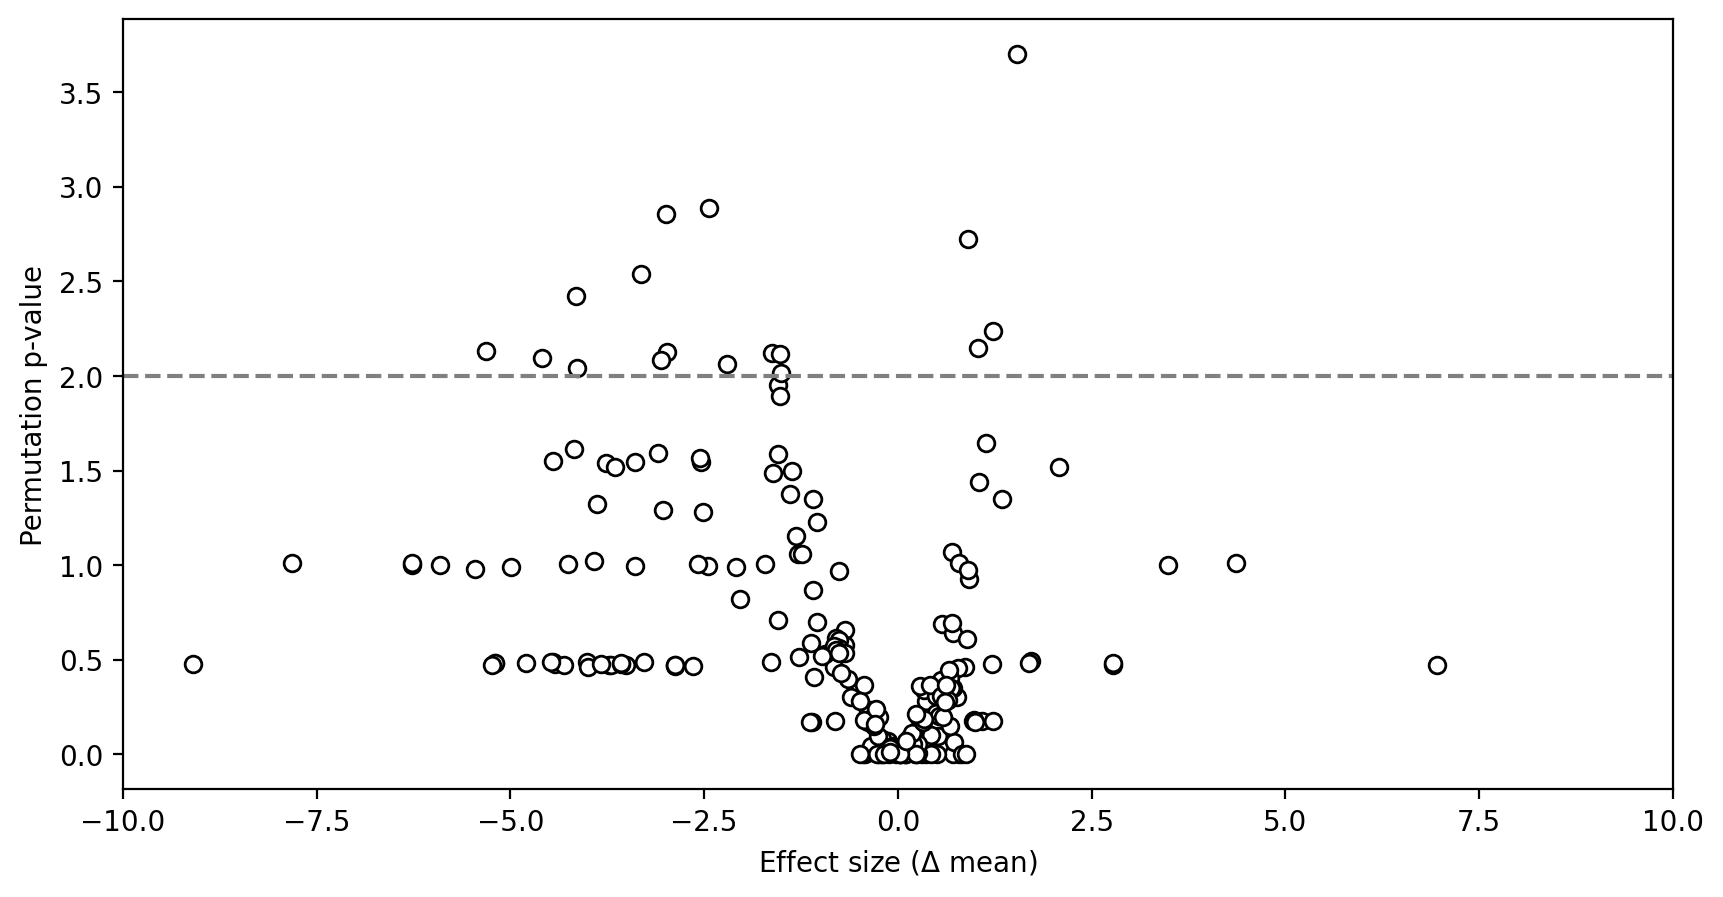

In [16]:
fig, ax = plt.subplots(figsize=(10,5))

x = test[("effect_size", "")].values
y = -np.log10(test[("permutation_pval", "")].values)

ax.scatter(x,y, edgecolors="k", facecolor="white")
ax.axhline(-np.log10(0.01), linestyle="--", color="grey")
ax.set(**{
    "xlabel": "Effect size ($\Delta$ mean)",
    "ylabel": "Permutation p-value",
    "xlim": (-10, 10)
})
import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/fig_volcano_permtest.pdf", bbox_inches="tight")
plt.show()

In [17]:
import numpy as np

def ECDF(values):
    values = np.sort(np.asarray(values, dtype=float))
    def evaluate(x):
        return np.searchsorted(values, x, side="right") / len(values)
    return evaluate

def plt_cdf(ax, df, modality):

    if modality == "image":
        dcolor = "#1f77b4"
        ncolor = "grey"
    elif modality == "text":
        dcolor = "#ff7f0e"
        ncolor = "grey"

    x = df.query(f"discussed & modality=='{modality}'")["metrics_rank"]
    y = df.query(f"~discussed & modality=='{modality}'")["metrics_rank"]

    ecdf_discussed = ECDF(x)
    ecdf_not = ECDF(y)

    x_vals = np.linspace(
        1, max(x.max(), 
            y.max()), 100)

    ax.plot(x_vals, ecdf_discussed(x_vals), label="Discussed", color=dcolor)
    ax.plot(x_vals, ecdf_not(x_vals), label="Not discussed", color=ncolor)

    ax.set(
        xlabel="Rank (1 = strongest)",
        ylabel="Cumulative Probability",
        title=f"CDF of gene rank ({modality.upper()})",
    )
    ax.legend()
    return ax

In [18]:
# IMAGE
#1f77b4 (blue)
# lighter: #f0f7fc

# TEXT
#ff7f0e (orange)
# ligher: #fff4e6

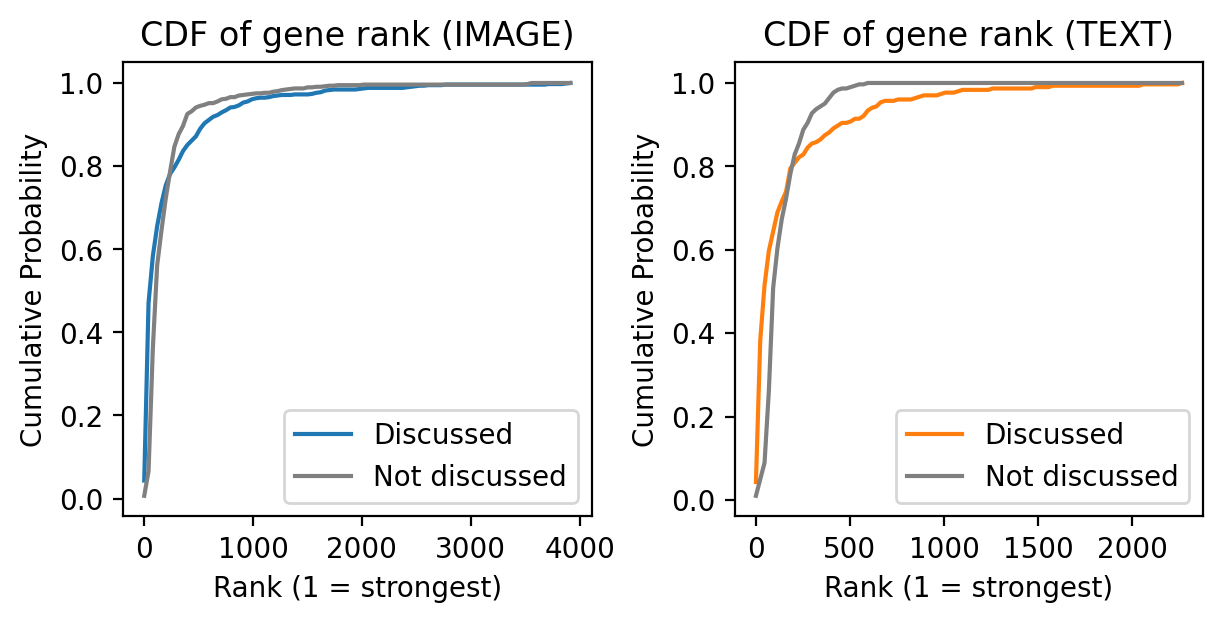

In [19]:
fig, axs = plt.subplots(figsize=(6,3), ncols=2, constrained_layout=True)

ax = axs[0]
plt_cdf(ax, data, "image")

ax = axs[1]
plt_cdf(ax, data, "text")
import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/fig_rank_cdf.pdf", bbox_inches="tight")
plt.show()

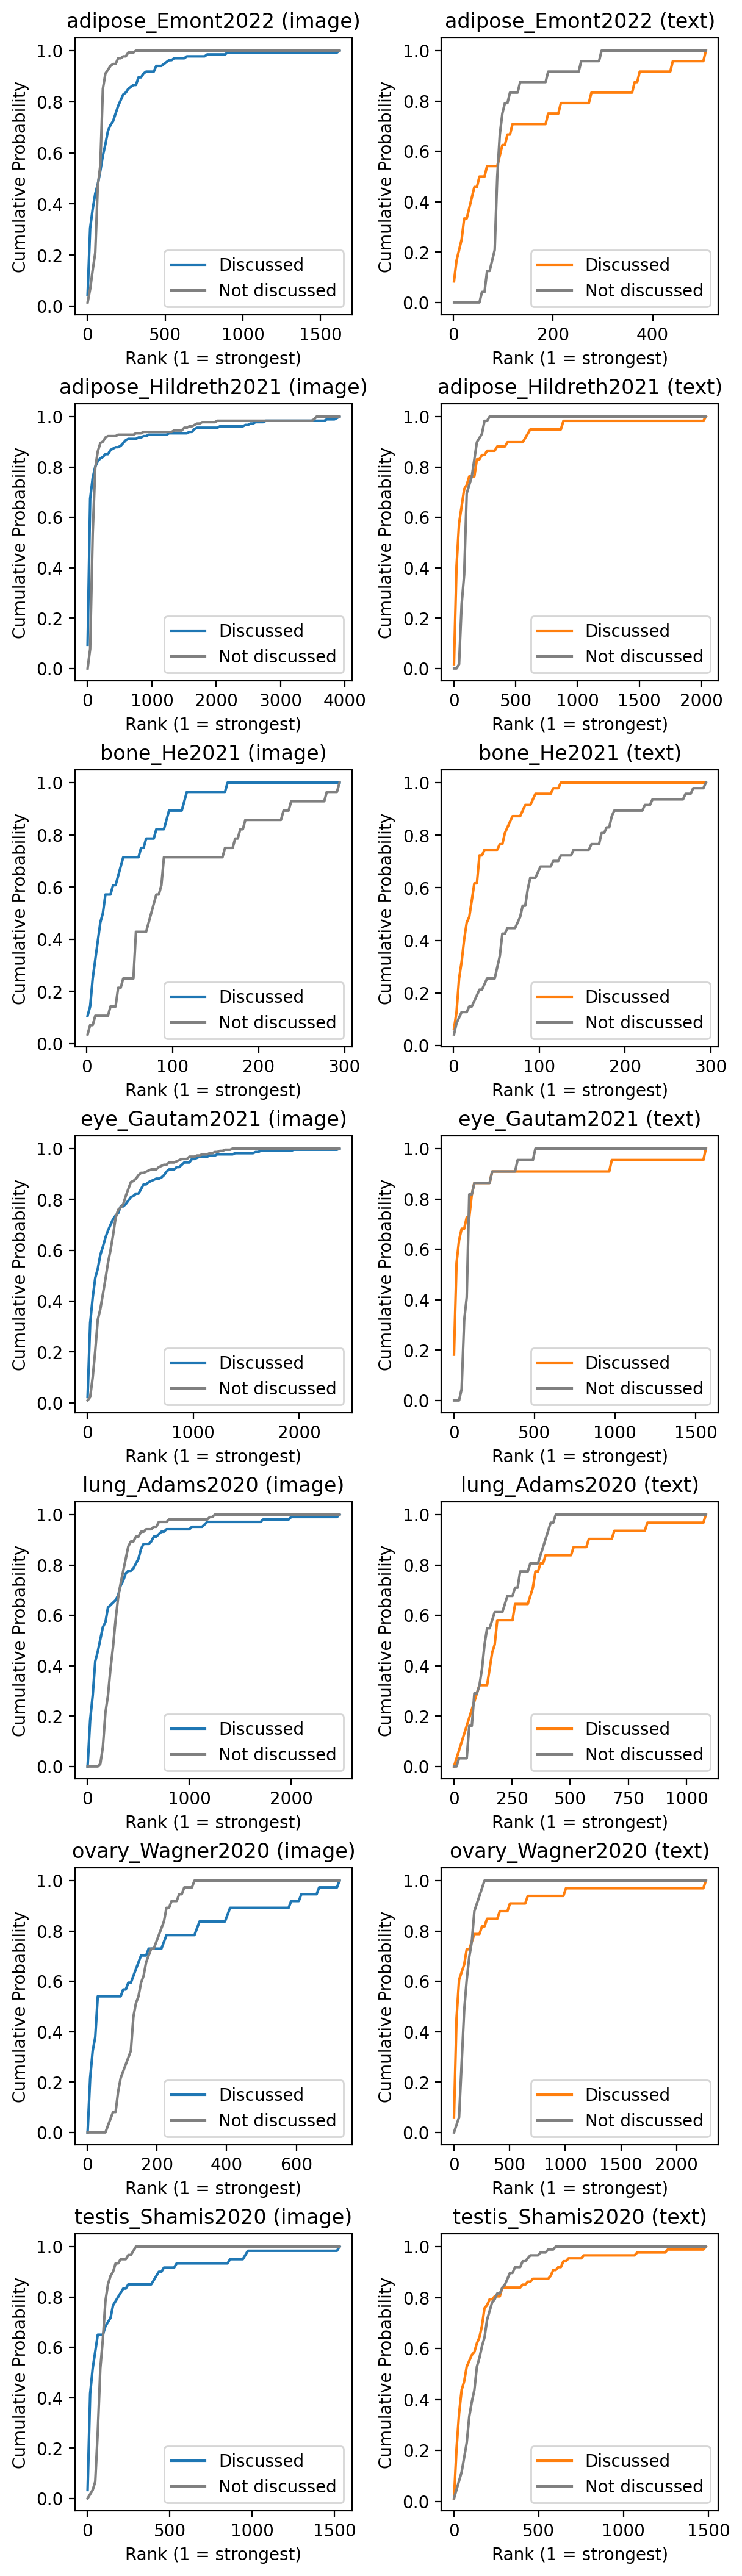

In [20]:
import matplotlib.pyplot as plt

nrows, ncols = 7, 2
side = 3  # inches per subplot side; tweak as you like


fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(side*ncols, side*nrows),  # ensures height/width ≈ 7/2
    constrained_layout=True
)

for i, dataset in enumerate(datasets):
    df = data.query(f"dataset == '{dataset}'")

    ax_img = axs[i, 0]
    ax_txt = axs[i, 1]

    plt_cdf(ax_img, df, "image")
    plt_cdf(ax_txt, df, "text")

    ax_img.set_title(f"{dataset} (image)")
    ax_txt.set_title(f"{dataset} (text)")

# force square boxes for every axes
for ax in axs.flat:
    ax.set_box_aspect(1)  # mpl >= 3.3

fig.show()

In [21]:
# IMAGE
#1f77b4 (blue)
# lighter: #f0f7fc

# TEXT
#ff7f0e (orange)
# ligher: #fff4e6

In [22]:
def bplot(ax, df, modality, col="metrics_logfc", yscale="log"):
    x = [
        df.query(f"discussed & modality=='{modality}'")[col].values,
        df.query(f"~discussed & modality=='{modality}'")[col].values
    ]
    if modality == "text":
        colors = ['#ff7f0e', '#fff4e6']
    elif modality == "image":
        colors = ["#1f77b4", "#f0f7fc"]
    xticks=[1, 2]

    bp = ax.boxplot(x, positions=xticks, widths=0.5, patch_artist=True,
                    medianprops={'visible': False},
                    showfliers=False,
                    showmeans=True,
                    meanline=True,
                    meanprops=dict(color='black', linewidth=2))

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    # add some jitter to the points
    space = 0.1
    y = x[0]
    xx = np.random.normal(1, 0.1, size=len(y))
    ax.scatter(xx, y, edgecolor="k", facecolor=colors[0], zorder=10, s=10)

    y = x[1]
    xx = np.random.normal(2, 0.1, size=len(y))
    ax.scatter(xx, y, edgecolor="k", facecolor=colors[1], zorder=10, s=10)

    ylabel = "Log Fold Change" if col == 'metrics_logfc' else "Rank"
    ax.set(**{
        "xticks": xticks,
        "xticklabels": ["Discussed", "Not Discussed"],
        "ylabel": ylabel,
        "title": f"{modality} markers",
        "yscale": yscale,

    })
    return ax

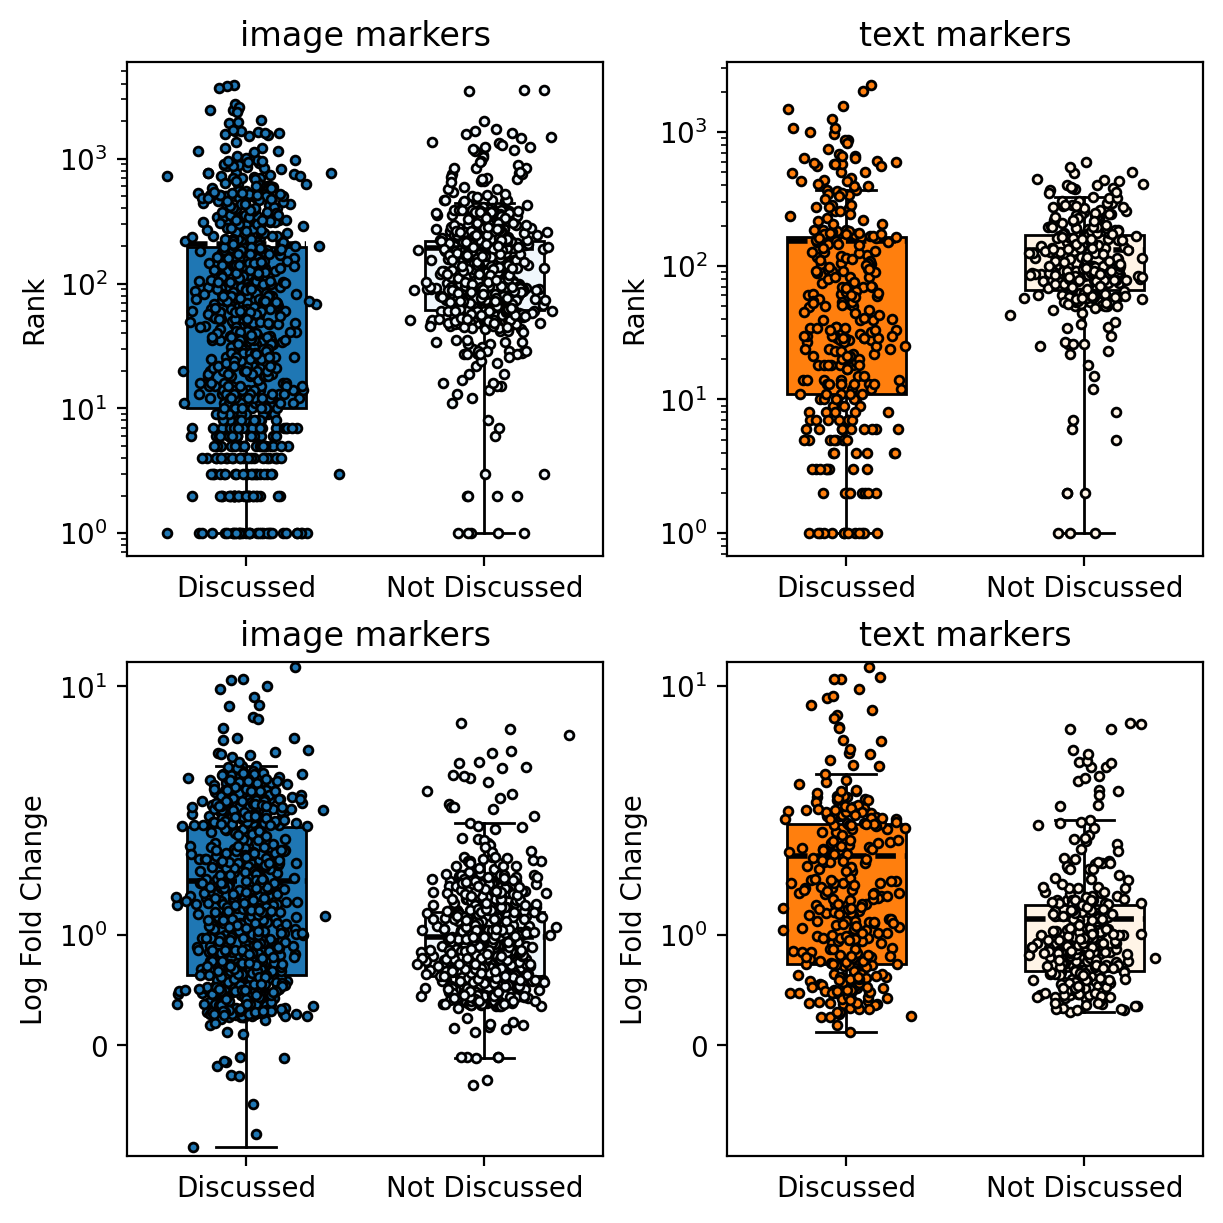

In [23]:
fig, axs = plt.subplots(figsize=(6, 6), ncols=2, nrows=2, constrained_layout = True)

ax = axs[0, 0]
bplot(ax, data, "image", "metrics_rank", yscale="log")
ax.set_ylim(0)

ax = axs[0, 1]
bplot(ax, data, "text", "metrics_rank", yscale="log")
ax.set_ylim(0)

##################################

ax = axs[1, 0]
bplot(ax, data, "image", yscale="symlog")
ax.set_ylim(-1)

ax = axs[1, 1]
bplot(ax, data, "text", yscale="symlog")
ax.set_ylim(-1)


import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/fig_rank_lfc_boxplot.pdf", bbox_inches="tight")
fig.show()

In [24]:
data.groupby(["modality"])["discussed"].value_counts()

modality  discussed
image     True         763
          False        763
text      True         303
          False        303
Name: count, dtype: int64

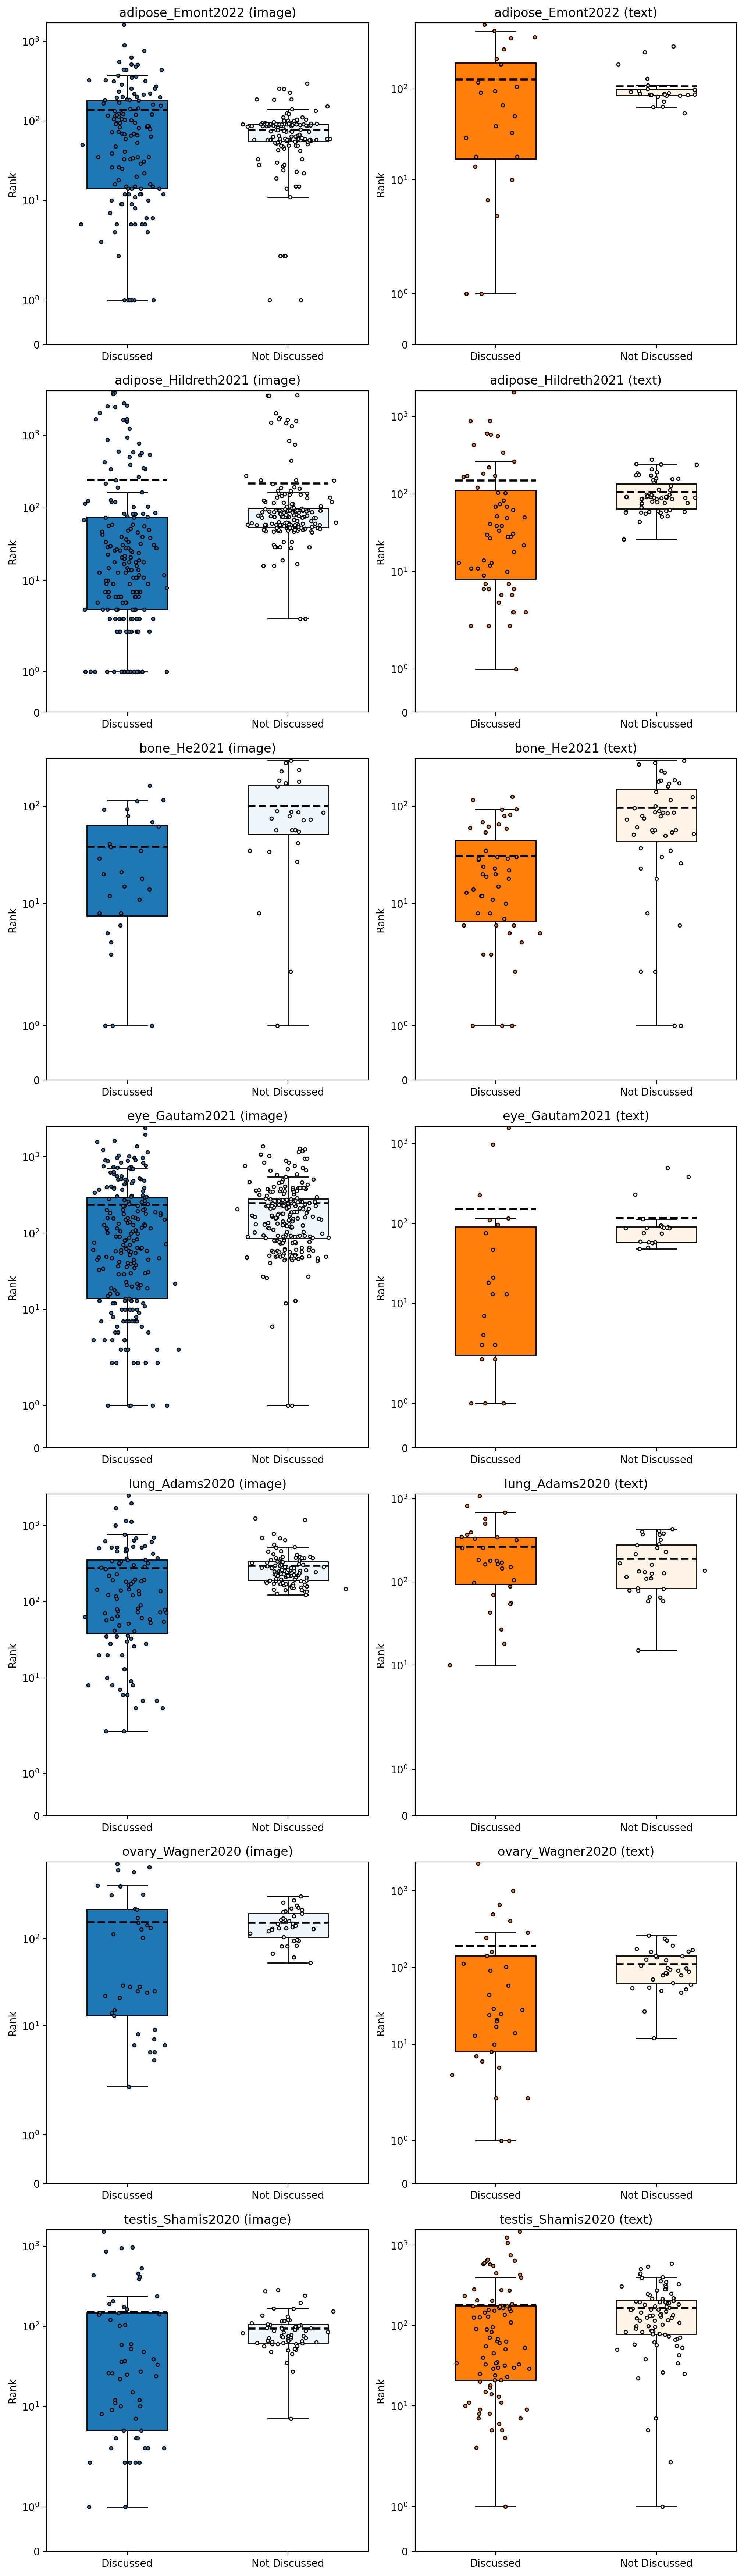

In [25]:
import matplotlib.pyplot as plt

nrows, ncols = 7, 2
side = 5  # inches per subplot side; tweak as you like


fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(side*ncols, side*nrows),  # ensures height/width ≈ 7/2
    constrained_layout=True
)

for i, dataset in enumerate(datasets):
    df = data.query(f"dataset == '{dataset}'")

    ax_img = axs[i, 0]
    ax_txt = axs[i, 1]

    bplot(ax_img, df, "image", "metrics_rank", yscale="symlog")
    bplot(ax_txt, df, "text", "metrics_rank", yscale="symlog")

    ax_img.set_title(f"{dataset} (image)")
    ax_txt.set_title(f"{dataset} (text)")
    ax_img.set_ylim(0)
    ax_txt.set_ylim(0)

# force square boxes for every axes
for ax in axs.flat:
    ax.set_box_aspect(1)  # mpl >= 3.3

fig.show()

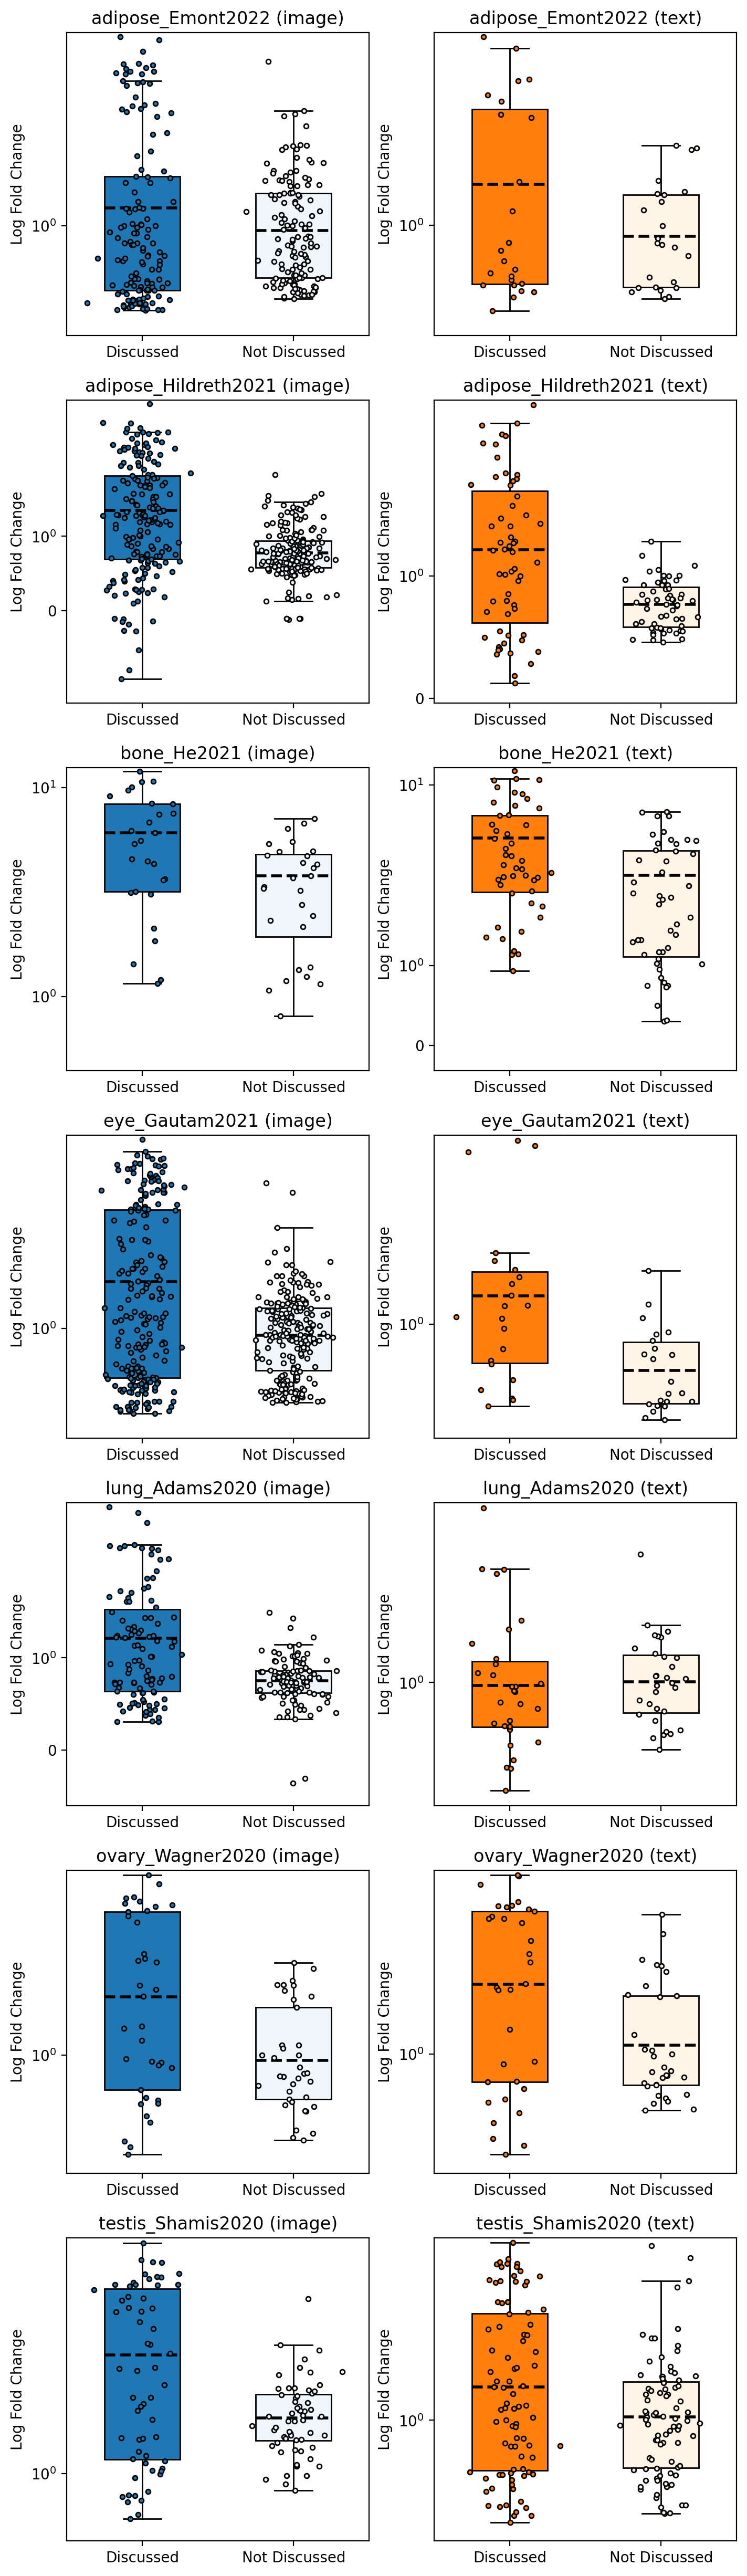

In [26]:
import matplotlib.pyplot as plt

nrows, ncols = 7, 2
side = 3.5  # inches per subplot side; tweak as you like


fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(side*ncols, side*nrows),  # ensures height/width ≈ 7/2
    constrained_layout=True
)

for i, dataset in enumerate(datasets):
    df = data.query(f"dataset == '{dataset}'")

    ax_img = axs[i, 0]
    ax_txt = axs[i, 1]

    bplot(ax_img, df, "image", "metrics_logfc", yscale="symlog")
    bplot(ax_txt, df, "text", "metrics_logfc", yscale="symlog")

    ax_img.set_title(f"{dataset} (image)")
    ax_txt.set_title(f"{dataset} (text)")
    # ax_img.set_ylim(0)
    # ax_txt.set_ylim(0)

# force square boxes for every axes
for ax in axs.flat:
    ax.set_box_aspect(1)  # mpl >= 3.3

fig.show()

In [27]:
import textwrap

def wrap_labels(labels, width=10):
    """Insert newlines into labels longer than `width`."""
    return ['\n'.join(textwrap.wrap(l, width)) for l in labels]

In [28]:
metric = "metrics_logfc"
min_markers = 2

df = data.query("dataset == 'adipose_Hildreth2021'")
ctplot = df.groupby(["modality", "group_name", "discussed"])[metric].apply(list)

img_ct = (ctplot.apply(lambda x: len(x) > min_markers)
    .reset_index()
    .query(metric)
    .groupby(["modality", "group_name"])["discussed"].count() == 2)["image"].index

txt_ct = (ctplot.apply(lambda x: len(x) > min_markers)
    .reset_index()
    .query(metric)
    .groupby(["modality", "group_name"])["discussed"].count() == 2)["text"].index

comm_ct = np.intersect1d(txt_ct, img_ct)

ctplot = ctplot[ctplot.index.get_level_values("group_name").isin(comm_ct)]

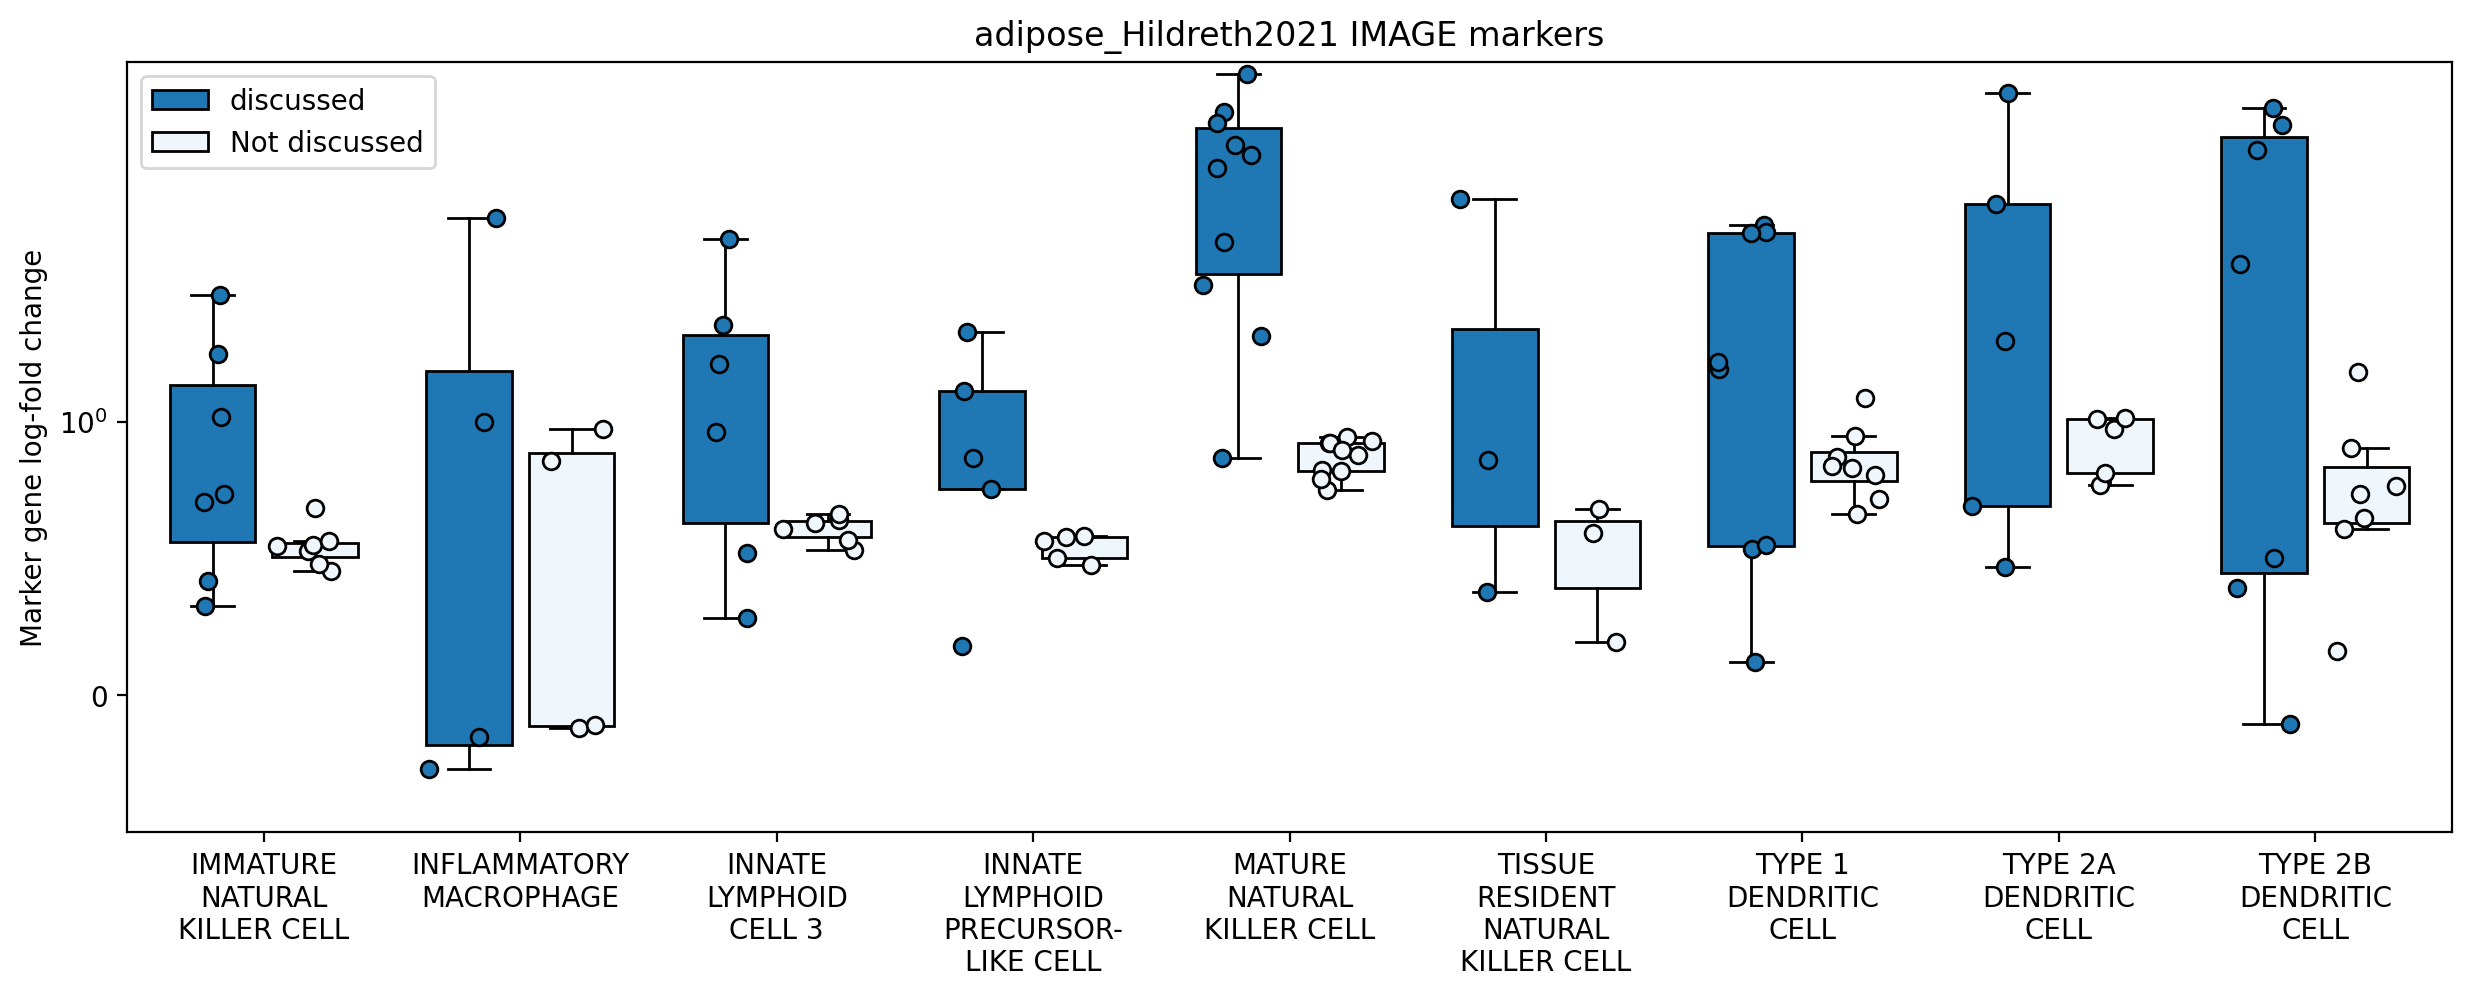

In [29]:
fig, ax = plt.subplots(figsize=(15, 5))

dist_bw = 1.5
space = 0.3

img_ctplot = ctplot["image"].copy()
labels = comm_ct
didx = [(l, True) for l in labels]
nidx = [(l, False) for l in labels]

d = img_ctplot.reindex(didx)
n = img_ctplot.reindex(nidx)

# Data preparation
x = d.values
y = n.values

idx = np.arange(len(labels)) * dist_bw

# Boxplots
ax.boxplot(x, positions=idx - space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='#1f77b4'), label="discussed", showfliers=False)
ax.boxplot(y, positions=idx + space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='#f0f7fc'), label="Not discussed", showfliers=False)

for i, xx, yy in zip(idx, x, y):
    xxx = np.random.normal(i-space, 0.1, size=len(xx))
    yyy = np.random.normal(i+space, 0.1, size=len(yy))
    ax.scatter(xxx, xx, edgecolor="k", facecolor="#1f77b4", zorder=10)
    ax.scatter(yyy, yy, edgecolor="k", facecolor="#f0f7fc", zorder=10)


# Formatting
ylabel = "Marker gene log-fold change"
ax.set(**{
    "xticks": np.arange(len(labels)) * dist_bw,
    "xticklabels": labels,
    "ylabel": ylabel,
    "title": f"adipose_Hildreth2021 IMAGE markers",
    "yscale": "symlog",
    "ylim": -0.5
})

wrapped_labels = wrap_labels(labels, width=12)

ax.set_xticks(np.arange(len(labels)) * dist_bw)
ax.set_xticklabels(wrapped_labels, rotation=0, ha='center', fontsize=10)

ax.legend()
plt.show()

In [30]:
# IMAGE
#1f77b4 (blue)
# lighter: #f0f7fc

# TEXT
#ff7f0e (orange)
# ligher: #fff4e6

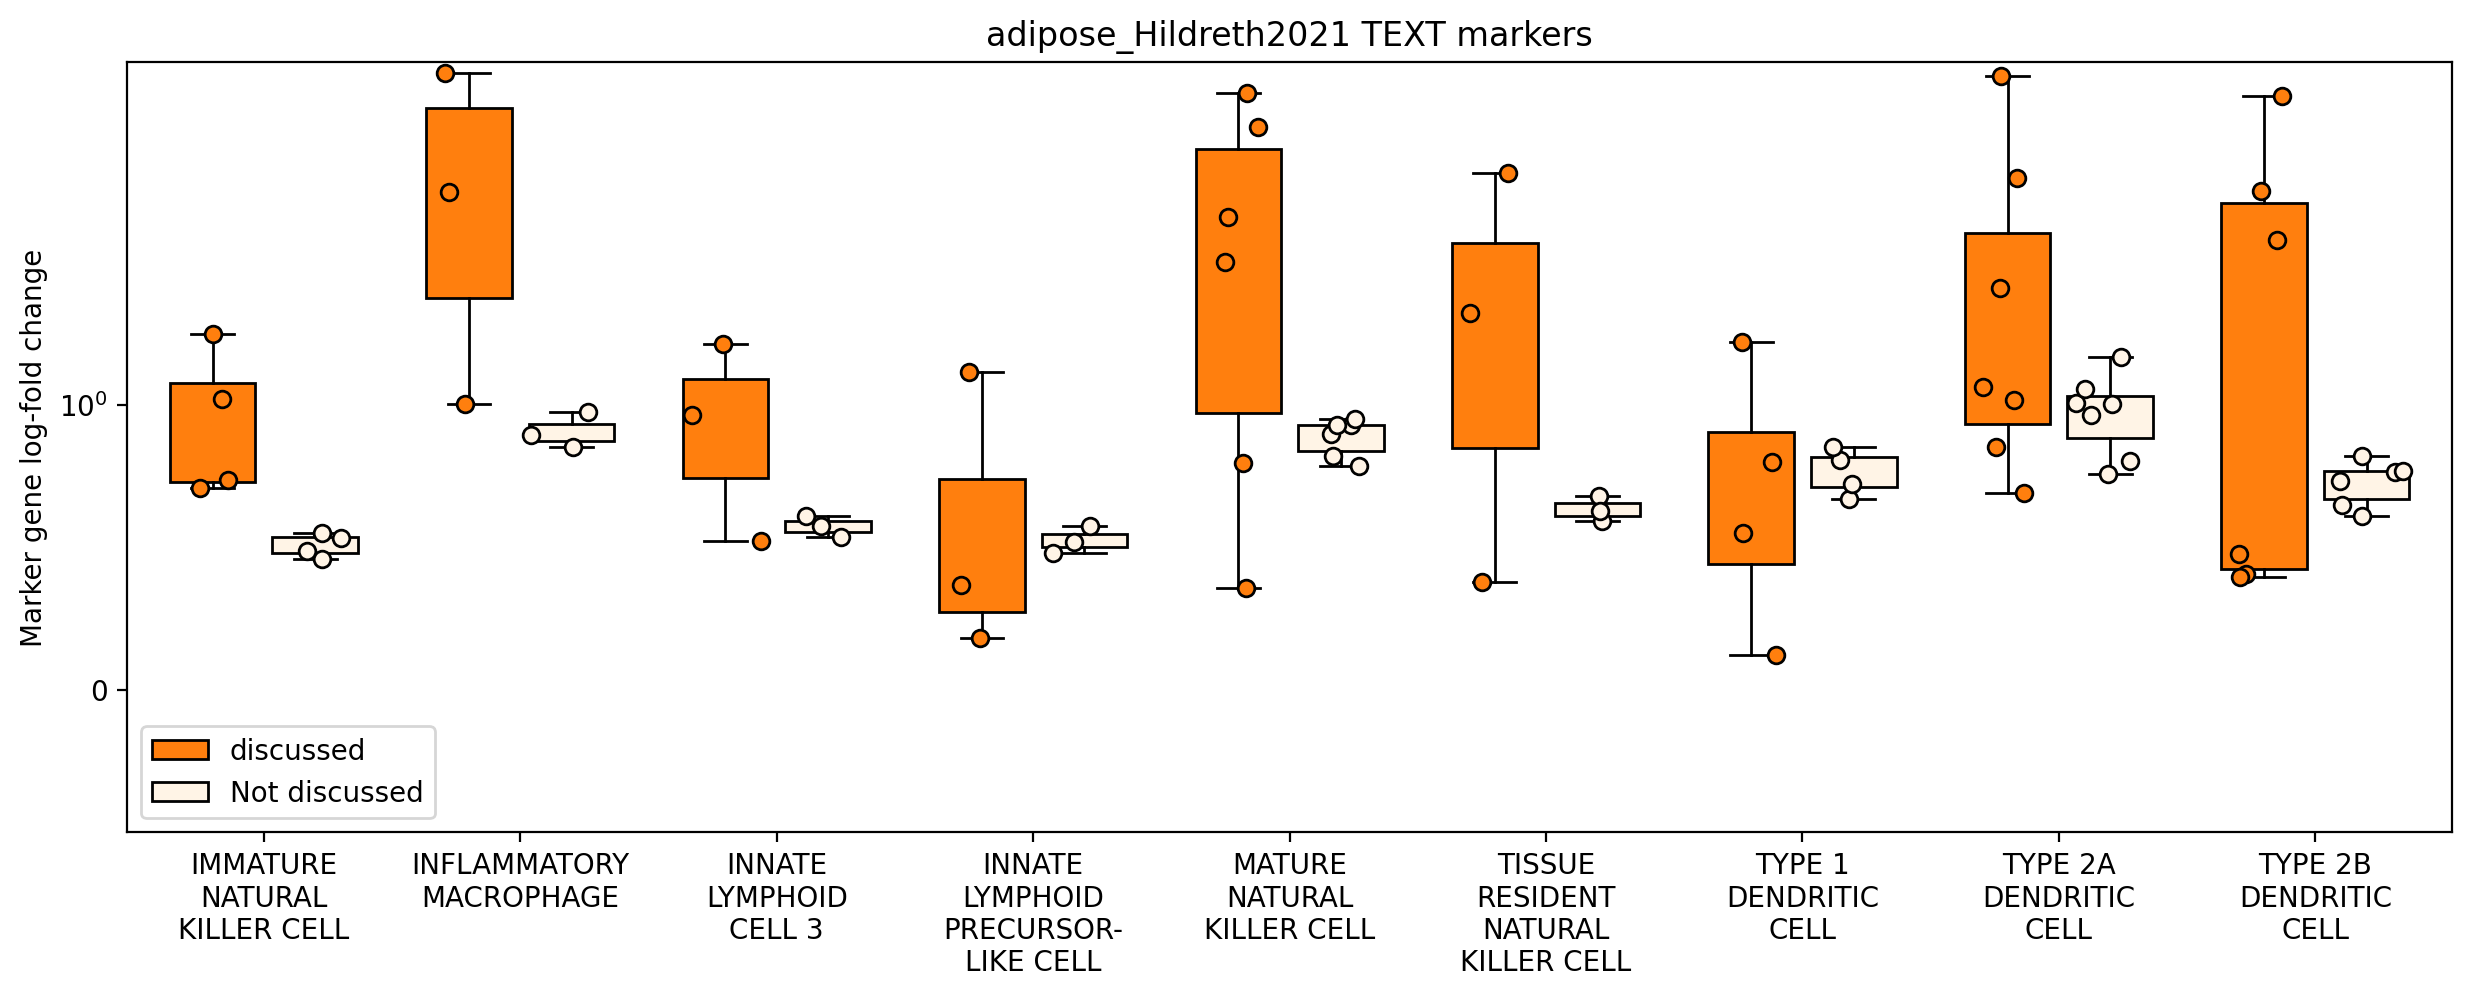

In [31]:
fig, ax = plt.subplots(figsize=(15, 5))

dist_bw = 1.5
space = 0.3

txt_ctplot = ctplot["text"].copy()
labels = comm_ct
didx = [(l, True) for l in labels]
nidx = [(l, False) for l in labels]

d = txt_ctplot.reindex(didx)
n = txt_ctplot.reindex(nidx)

# Data preparation
x = d.values
y = n.values

idx = np.arange(len(labels)) * dist_bw

# Boxplots
ax.boxplot(x, positions=idx - space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='#ff7f0e'), label="discussed", showfliers=False)
ax.boxplot(y, positions=idx + space, widths=0.5, patch_artist=True, medianprops={'visible': False}, boxprops=dict(facecolor='#fff4e6'), label="Not discussed", showfliers=False)

for i, xx, yy in zip(idx, x, y):
    xxx = np.random.normal(i-space, 0.1, size=len(xx))
    yyy = np.random.normal(i+space, 0.1, size=len(yy))
    ax.scatter(xxx, xx, edgecolor="k", facecolor="#ff7f0e", zorder=10)
    ax.scatter(yyy, yy, edgecolor="k", facecolor="#fff4e6", zorder=10)


# Formatting
ylabel = "Marker gene log-fold change"
ax.set(**{
    "xticks": np.arange(len(labels)) * dist_bw,
    "xticklabels": labels,
    "ylabel": ylabel,
    "title": f"adipose_Hildreth2021 TEXT markers",
    "yscale": "symlog",
    "ylim": -0.5
})

wrapped_labels = wrap_labels(labels, width=12)

ax.set_xticks(np.arange(len(labels)) * dist_bw)
ax.set_xticklabels(wrapped_labels, rotation=0, ha='center', fontsize=10)

ax.legend()
plt.show()

In [32]:
# per cell-type logfc averaged across all genes in text vs in image
modality = "image"
metric = "metrics_logfc"
ylabel = "Marker gene log-fold change"
min_markers = 2

img_mean = data.query(f"modality == 'image' and discussed").groupby(["group_name",])[metric].apply(np.mean)
txt_mean = data.query(f"modality == 'text' and discussed").groupby(["group_name",])[metric].apply(np.mean)

common_idx = img_mean.index.intersection(txt_mean.index)

In [33]:
# Text vs image gene overlap per cell type
txt_genes = ext.reset_index().query("source_type == 'text'").groupby("group_name")["feature_id"].apply(set)
img_genes = ext.reset_index().query("source_type == 'image'").groupby("group_name")["feature_id"].apply(set)
common_cts = txt_genes.index.intersection(img_genes.index)

overlaps = []
for ct in common_cts:
    t, i = txt_genes[ct], img_genes[ct]
    shared = len(t & i)
    union = len(t | i)
    overlaps.append({"ct": ct, "txt": len(t), "img": len(i), "shared": shared,
                     "jaccard": shared / union if union else 0})

overlap_df = pd.DataFrame(overlaps)
print(f"Cell types with both text + image markers: {len(overlap_df)}")
print(f"Median gene overlap (Jaccard): {overlap_df.jaccard.median():.2f}")
print(f"Mean gene overlap (Jaccard):   {overlap_df.jaccard.mean():.2f}")
print(f"Zero overlap: {(overlap_df.shared == 0).sum()} / {len(overlap_df)}")

Cell types with both text + image markers: 74
Median gene overlap (Jaccard): 0.33
Mean gene overlap (Jaccard):   0.41
Zero overlap: 7 / 74


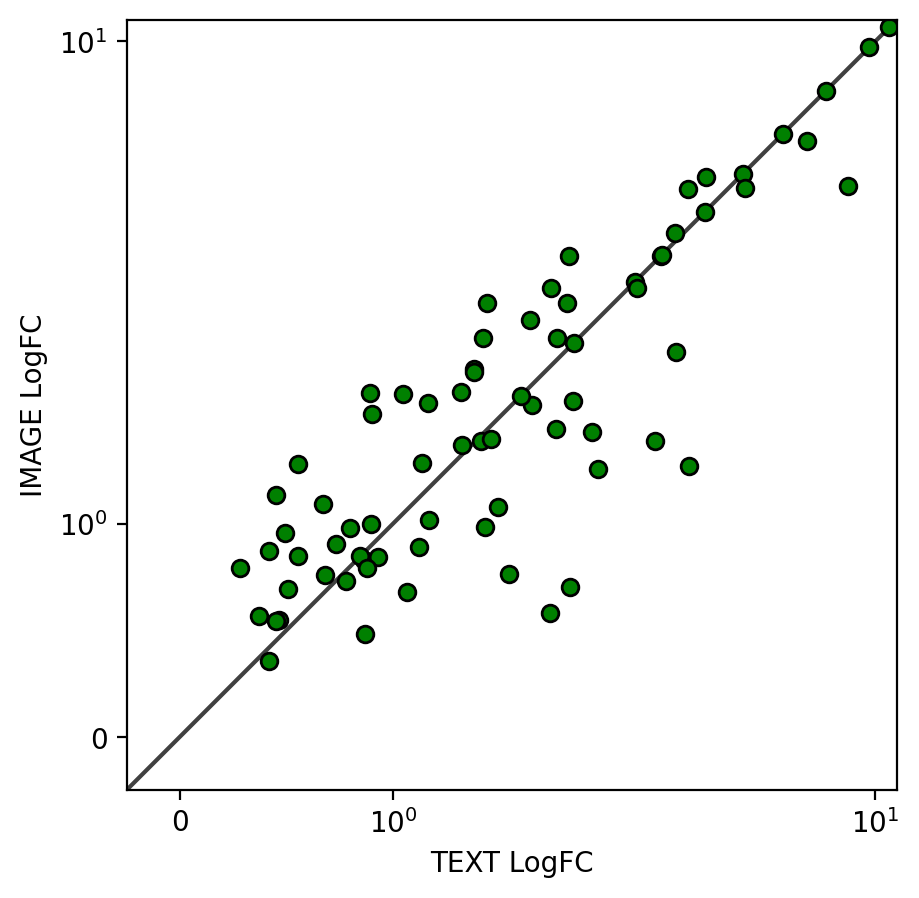

In [34]:
fig, ax = plt.subplots(figsize = (5,5))

x = txt_mean[common_idx]
y = img_mean[common_idx]

ax.scatter(x,y, color="green", edgecolor="k")
yex(ax)

ax.set(**{
    "xlabel": "TEXT LogFC",
    "ylabel": "IMAGE LogFC",
    "yscale": "symlog",
    "xscale": "symlog",
})
# plt.tick_params(axis='both', which='minor', labelsize=5)
fig.show()

In [35]:
from itertools import chain

# This returns a Series where each value is a list of ranks

s = data.query("discussed").groupby(["data_id", "modality", "group_name"])["metrics_rank"].apply(lambda x: sorted(list(map(int, x))))

# Flatten all lists, deduplicate, and sort
all_unique_ranks = sorted(set(chain.from_iterable(s)))

In [36]:
from itertools import chain

# Group by dataset and modality, flatten and deduplicate the rank lists
# agg = (
#     data.query("discussed")
#     .groupby(["dataset", "modality"])["metrics_rank"]
#     .apply(lambda x: sorted(set(list(map(int, x)))))
#     .unstack("modality")  # makes one column per modality
#     .reset_index()
# )

agg = (
    ext
    .groupby(["ds_name", "source_type"])["metrics_rank"]
    .apply(lambda x: sorted(set(list(map(int, x)))))
    .unstack("source_type")  # makes one column per modality
    .reset_index()
)

In [37]:
data.query("discussed and modality == 'text'").groupby("dataset")["metrics_rank"].apply(lambda x: np.sort(x))

dataset
adipose_Emont2022       [1.0, 1.0, 4.0, 6.0, 10.0, 14.0, 18.0, 18.0, 2...
adipose_Hildreth2021    [1.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 4.0, 5.0, ...
bone_He2021             [1.0, 1.0, 1.0, 2.0, 3.0, 3.0, 4.0, 5.0, 5.0, ...
eye_Gautam2021          [1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 3.0, 3.0, 4.0, ...
lung_Adams2020          [10.0, 18.0, 27.0, 43.0, 54.0, 56.0, 70.0, 88....
ovary_Wagner2020        [1.0, 1.0, 2.0, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...
testis_Shamis2020       [1.0, 3.0, 4.0, 5.0, 5.0, 6.0, 7.0, 7.0, 8.0, ...
Name: metrics_rank, dtype: object

In [38]:
agg

source_type,ds_name,image,text
0,adipose_Emont2022,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15...","[1, 4, 6, 10, 14, 18, 29, 33, 39, 50, 66, 91, ..."
1,adipose_Hildreth2021,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 1..."
2,bone_He2021,"[1, 3, 4, 5, 6, 8, 11, 12, 14, 15, 18, 20, 21,...","[1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 1..."
3,eye_Gautam2021,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 7, 13, 18, 21, 47, 76, 96, 109, 1..."
4,lung_Adams2020,"[2, 4, 5, 6, 7, 8, 9, 10, 13, 20, 26, 28, 30, ...","[10, 18, 27, 43, 54, 56, 70, 88, 98, 105, 145,..."
5,ovary_Wagner2020,"[2, 4, 5, 6, 7, 8, 9, 13, 14, 15, 21, 22, 24, ...","[1, 2, 4, 5, 6, 7, 8, 10, 13, 14, 17, 20, 21, ..."
6,testis_Shamis2020,"[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 15, 22, 2...","[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 1..."


In [39]:
def compute_fractions(ranks: list[int], n: int) -> tuple[float, float]:
    ranks = sorted(ranks)
    total = len(ranks) # TP + FN
    in_top_n = sum(1 for r in ranks if r <= n) # TP

    recall = in_top_n / total if total > 0 else 0 # TP / (TP + FN) Recall, frac_top_n_of_total
    precision = in_top_n / n if n > 0 else 0 # TP / (TP + FP) Precision frac_top_n_of_n

    return (precision, recall)

def compute_fraction_curve(ranks: list[int], max_n: int = None, step: int = 1):
    if max_n is None:
        max_n = max(ranks)

    results = []
    for n in range(1, max_n + 1, step):
        precision, recall = compute_fractions(ranks, n)
        if precision + recall == 0:
            f = 0
        else:
            f = 2 * (precision * recall)/(precision + recall)
        results.append((n, precision, recall, f))

    return np.array(results)


In [40]:
agg = agg.assign(
    curve_text = agg["text"].apply(lambda r: compute_fraction_curve(r, max_n=20000, step=5)),
    curve_image = agg["image"].apply(lambda r: compute_fraction_curve(r, max_n=20000, step=5)),
)

In [41]:
agg

source_type,ds_name,image,text,curve_text,curve_image
0,adipose_Emont2022,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15...","[1, 4, 6, 10, 14, 18, 29, 33, 39, 50, 66, 91, ...","[[1.0, 1.0, 0.045454545454545456, 0.0869565217...","[[1.0, 1.0, 0.010416666666666666, 0.0206185567..."
1,adipose_Hildreth2021,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 1...","[[1.0, 1.0, 0.021739130434782608, 0.0425531914...","[[1.0, 1.0, 0.01098901098901099, 0.02173913043..."
2,bone_He2021,"[1, 3, 4, 5, 6, 8, 11, 12, 14, 15, 18, 20, 21,...","[1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 1...","[[1.0, 1.0, 0.027777777777777776, 0.0540540540...","[[1.0, 1.0, 0.04, 0.07692307692307693], [6.0, ..."
3,eye_Gautam2021,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 7, 13, 18, 21, 47, 76, 96, 109, 1...","[[1.0, 1.0, 0.0625, 0.11764705882352941], [6.0...","[[1.0, 1.0, 0.006369426751592357, 0.0126582278..."
4,lung_Adams2020,"[2, 4, 5, 6, 7, 8, 9, 10, 13, 20, 26, 28, 30, ...","[10, 18, 27, 43, 54, 56, 70, 88, 98, 105, 145,...","[[1.0, 0.0, 0.0, 0.0], [6.0, 0.0, 0.0, 0.0], [...","[[1.0, 0.0, 0.0, 0.0], [6.0, 0.666666666666666..."
5,ovary_Wagner2020,"[2, 4, 5, 6, 7, 8, 9, 13, 14, 15, 21, 22, 24, ...","[1, 2, 4, 5, 6, 7, 8, 10, 13, 14, 17, 20, 21, ...","[[1.0, 1.0, 0.03225806451612903, 0.0625], [6.0...","[[1.0, 0.0, 0.0, 0.0], [6.0, 0.666666666666666..."
6,testis_Shamis2020,"[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 15, 22, 2...","[1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 1...","[[1.0, 1.0, 0.013157894736842105, 0.0259740259...","[[1.0, 1.0, 0.021739130434782608, 0.0425531914..."


In [42]:
import numpy as np

def find_elbow_index(f1_scores: list[float]) -> int:
    f1 = np.array(f1_scores)
    n = len(f1)
    x = np.arange(n)

    # Line from first to last point
    line_start = np.array([0, f1[0]])
    line_end = np.array([n - 1, f1[-1]])
    line_vec = line_end - line_start

    # Normalize
    line_vec = line_vec / np.linalg.norm(line_vec)

    # Compute distance from each point to line
    vecs = np.stack([x, f1], axis=1) - line_start
    proj = vecs @ line_vec
    proj_point = np.outer(proj, line_vec) + line_start
    distances = np.linalg.norm(vecs - proj_point, axis=1)

    # Index of max distance = elbow
    return int(np.argmax(distances))

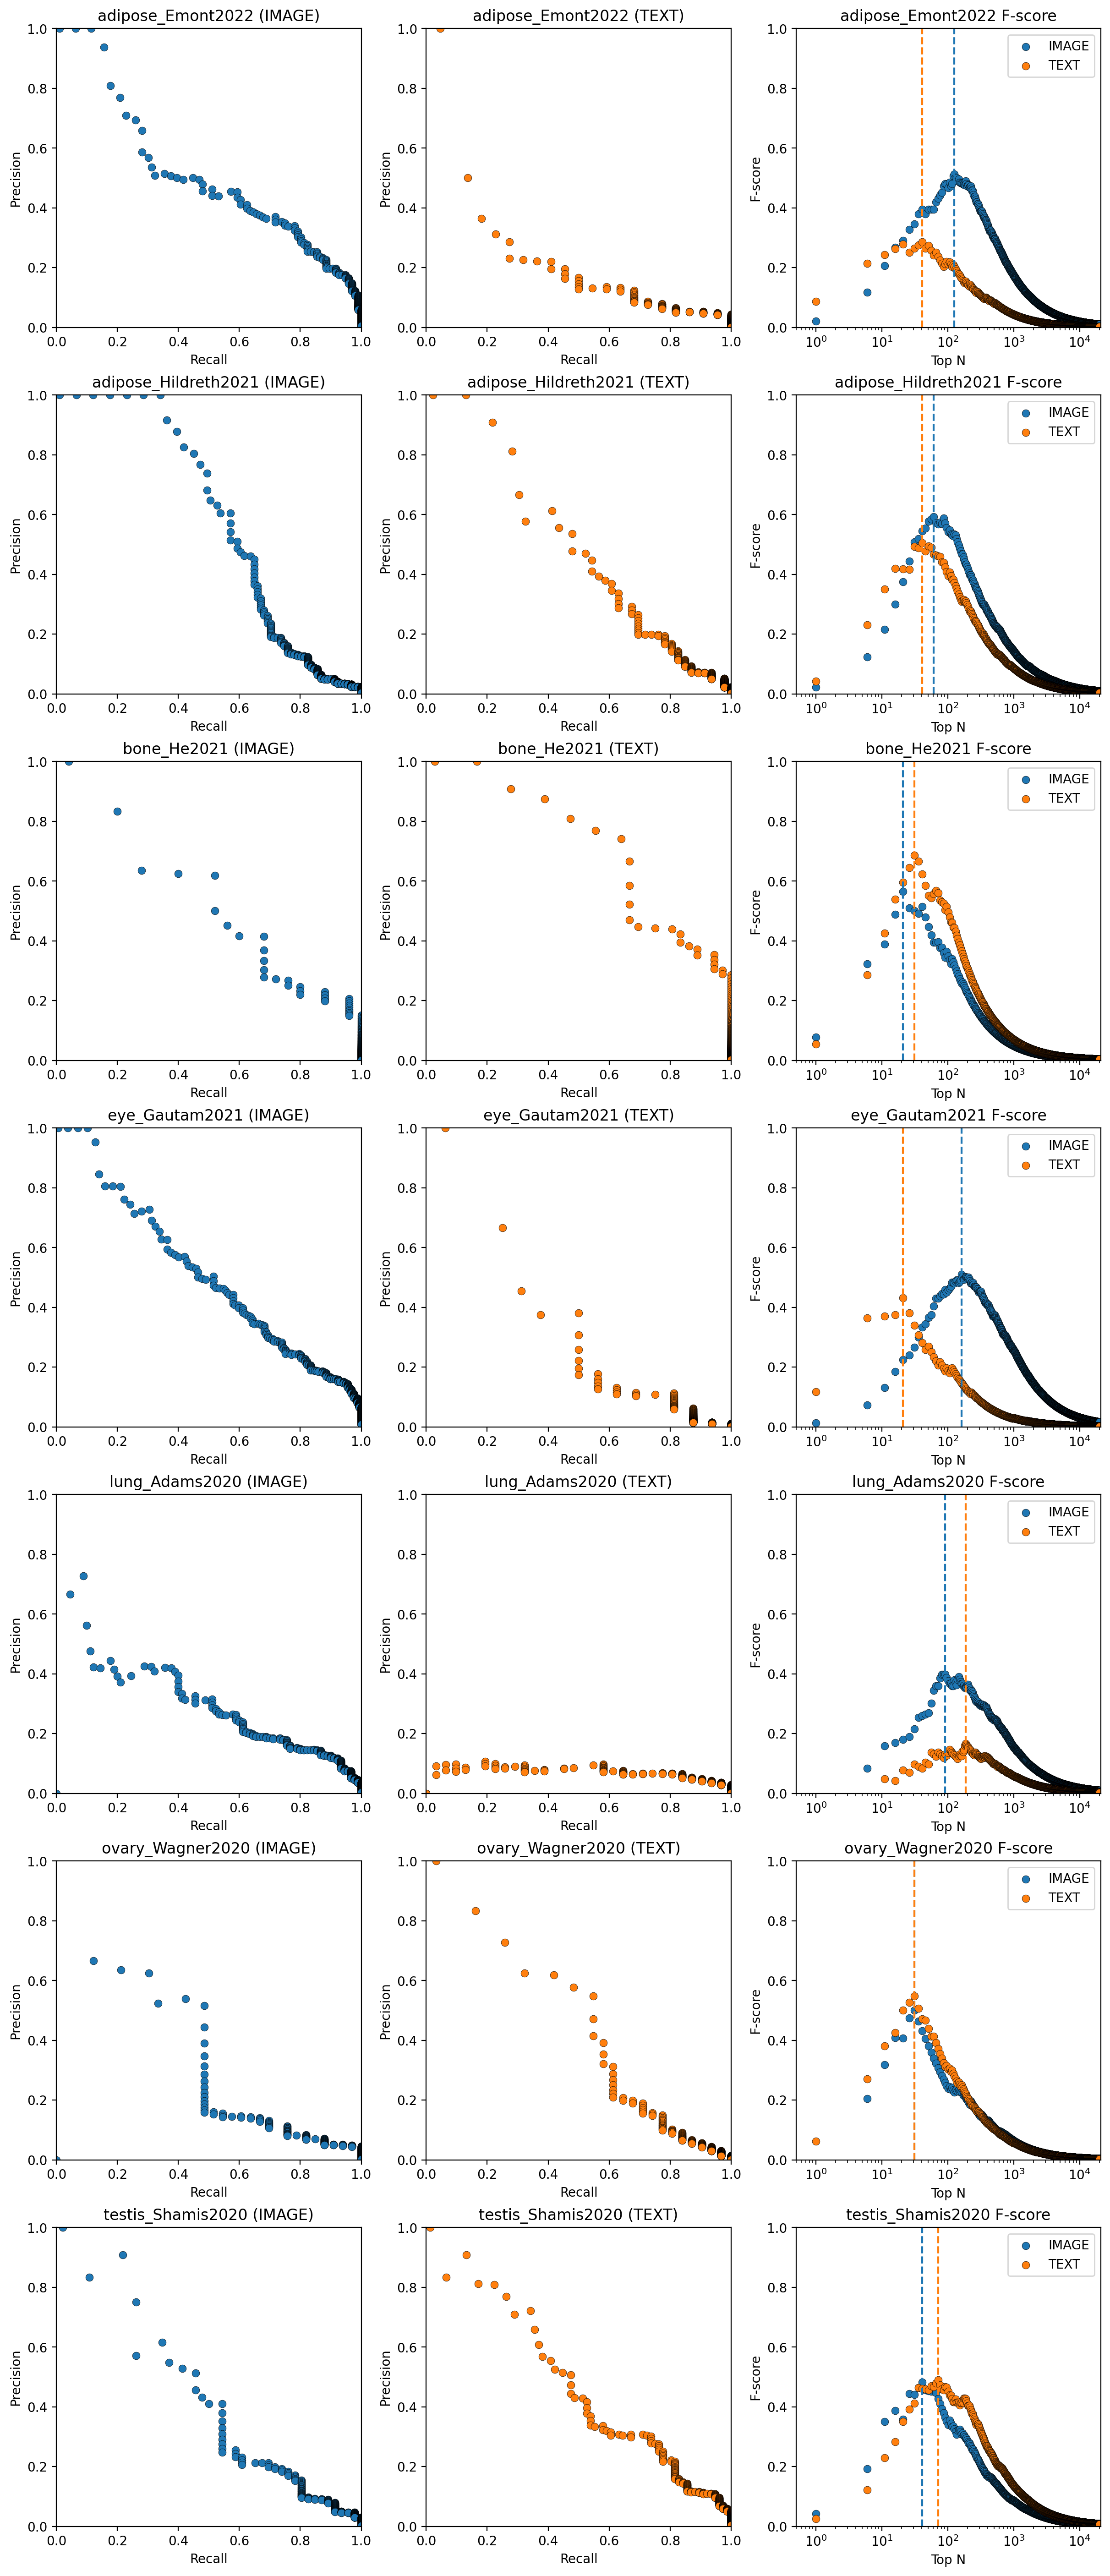

In [43]:
fig, axs =  plt.subplots(figsize=(12,28), ncols=3, nrows=len(datasets), constrained_layout=True)

for i, dataset in enumerate(datasets):
    ax = axs[i, 0]
    x = agg["curve_image"].iloc[i][:,2] # recall
    y = agg["curve_image"].iloc[i][:,1] # precision
    ax.scatter(x,y, edgecolor="k", linewidth=0.25)
    ax.set(**{
        "xlabel": "Recall",
        "ylabel": "Precision",
        "xlim": (0,1),
        "ylim": (0,1),
        "title": f"{dataset} (IMAGE)"
    })

    ax = axs[i, 1]
    x = agg["curve_text"].iloc[i][:,2] # recall
    y = agg["curve_text"].iloc[i][:,1] # precision
    ax.scatter(x,y, color="#ff7f0e", edgecolor="k", linewidth=0.25)
    ax.set(**{
        "xlabel": "Recall",
        "ylabel": "Precision",
        "xlim": (0,1),
        "ylim": (0,1),
        "title": f"{dataset} (TEXT)"
    })

    ax = axs[i, 2]
    n_vals = agg["curve_image"].iloc[i][:,0]
    f_vals = agg["curve_image"].iloc[i][:,3]
    # filter out 0 fvals
    x = n_vals[f_vals > 0]
    y = f_vals[f_vals > 0]

    ax.scatter(x,y, label="IMAGE", edgecolor="k", linewidth=0.25)

    idx = np.argmax(y)
    ax.axvline(x[idx], linestyle = "--", color="#1f77b4")
    
    n_vals = agg["curve_text"].iloc[i][:,0]
    f_vals = agg["curve_text"].iloc[i][:,3]
    # filter out 0 fvals
    x = n_vals[f_vals > 0]
    y = f_vals[f_vals > 0]

    ax.scatter(x,y, label="TEXT", edgecolor="k", linewidth=0.25)

    idx = np.argmax(y)
    ax.axvline(x[idx], linestyle = "--", color="#ff7f0e")
               
    ax.set(**{
        "xlabel": "Top N",
        "ylabel": "F-score",
        "xlim": 0.5,
        "ylim": (0,1),
        "xscale": "log",
        # "yscale": "log",
        "title": f"{dataset} F-score"
    })
    ax.legend()
import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/fig_fscore_topn.pdf", bbox_inches="tight")
plt.show()

In [44]:
summary_txt = []
for idx, row in agg.iterrows():
    argmax = row["curve_text"][:,3].argmax()
    summary_txt.append(
            {"dataset": row["ds_name"],
            "min_n": np.array(row["text"]).min().astype(int),
            "max_n": np.array(row["text"]).max().astype(int),
            "mean_n": np.array(row["text"]).mean().astype(int),
            "median": np.median(np.array(row["text"])).astype(int),
            "opt_n": row["curve_text"][:,0][argmax].astype(int), # n @ max f
            "opt_r": row["curve_text"][:,2][argmax], # recall @ max f
            "opt_p": row["curve_text"][:,1][argmax], # precision @ max f
            "opt_f": row["curve_text"][:,3][argmax]  # @ max f
            }
    )

summary_img = []
for idx, row in agg.iterrows():
    argmax = row["curve_image"][:,3].argmax()
    summary_img.append(
            {"dataset": row["ds_name"],
            "min_n": np.array(row["image"]).min().astype(int),
            "max_n": np.array(row["image"]).max().astype(int),
            "mean_n": np.array(row["image"]).mean().astype(int),
            "median": np.median(np.array(row["image"])).astype(int),
            "opt_n": row["curve_image"][:,0][argmax].astype(int), # n @ max f
            "opt_r": row["curve_image"][:,2][argmax], # recall @ max f
            "opt_p": row["curve_image"][:,1][argmax], # precision @ max f
            "opt_f": row["curve_image"][:,3][argmax]  # @ max f
            }
    )

In [45]:
txt = pd.DataFrame(summary_txt).sort_values("max_n").reset_index(drop=True)
img = pd.DataFrame(summary_img).sort_values("max_n").reset_index(drop=True)

In [46]:
txt

,dataset,min_n,max_n,mean_n,median,opt_n,opt_r,opt_p,opt_f
0,bone_He2021,1,125,36,22,31,0.638889,0.741935,0.686567
1,adipose_Emont2022,1,507,137,78,41,0.409091,0.219512,0.285714
2,lung_Adams2020,10,1083,264,180,186,0.580645,0.096774,0.165899
3,testis_Shamis2020,1,1485,202,90,71,0.473684,0.507042,0.489796
4,eye_Gautam2021,1,1564,204,34,21,0.500000,0.380952,0.432432
5,adipose_Hildreth2021,1,2038,186,49,41,0.478261,0.536585,0.505747
6,ovary_Wagner2020,1,2263,203,28,31,0.548387,0.548387,0.548387


In [47]:
txt.opt_n.mean().astype(int)

np.int64(60)

In [48]:
img

,dataset,min_n,max_n,mean_n,median,opt_n,opt_r,opt_p,opt_f
0,bone_He2021,1,163,42,21,21,0.520000,0.619048,0.565217
1,ovary_Wagner2020,2,724,170,102,31,0.484848,0.516129,0.500000
2,testis_Shamis2020,1,1530,195,55,41,0.456522,0.512195,0.482759
3,adipose_Emont2022,1,1622,173,104,126,0.593750,0.452381,0.513514
4,eye_Gautam2021,1,2380,318,158,161,0.515924,0.503106,0.509434
5,lung_Adams2020,2,2476,303,145,91,0.400000,0.395604,0.397790
6,adipose_Hildreth2021,1,3915,471,69,61,0.494505,0.737705,0.592105


In [49]:
img.opt_n.mean().astype(int)

np.int64(76)

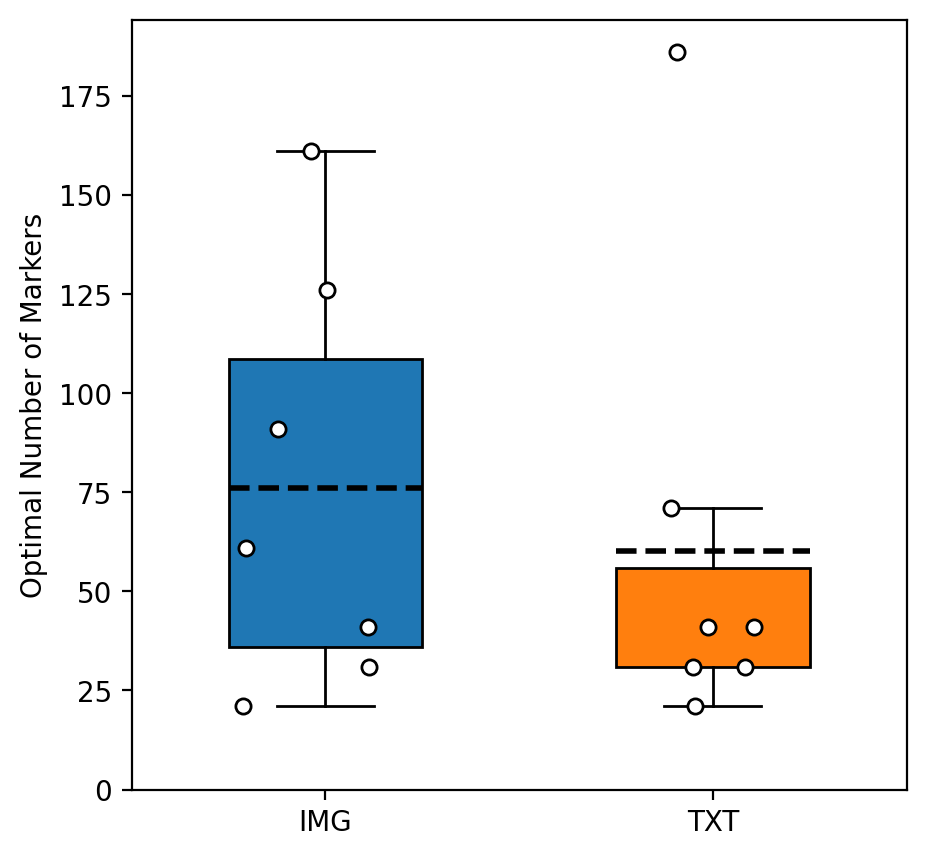

In [50]:
fig, ax = plt.subplots(figsize=(5,5))

x = [img.opt_n, txt.opt_n]
colors = ["#1f77b4", "#ff7f0e",]
# colors = ['green', 'red']
xticks=[1, 2]

bp = ax.boxplot(x, positions=xticks, widths=0.5, patch_artist=True,
                medianprops={'visible': False},
                showfliers=False,
                showmeans=True,
                meanline=True,
                meanprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# add some jitter to the points
space = 0.1
y = x[0]
xx = np.random.normal(1, 0.1, size=len(y))
ax.scatter(xx, y, edgecolor="k", facecolor="white", zorder=10, s=30)

y = x[1]
xx = np.random.normal(2, 0.1, size=len(y))
ax.scatter(xx, y, edgecolor="k", facecolor="white", zorder=10, s=30)

ylabel = "Optimal Number of Markers"
ax.set(**{
    "xticks": xticks,
    "xticklabels": ["IMG", "TXT"],
    "ylabel": ylabel,
    "ylim": (0)
})
import os
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/fig_optimal_n.pdf", bbox_inches="tight")
plt.show()

## Combined figure: Marker gene selection

Four-panel figure for the "Marker gene selection" subsection of the manuscript:
- **(a)** CDF of discussed marker DEG ranks (text vs image)
- **(b)** Discussed vs non-discussed rank boxplots
- **(c)** Mean log-fold change for text versus image markers
- **(d)** Optimal DEG cutoff versus F-score at that cutoff

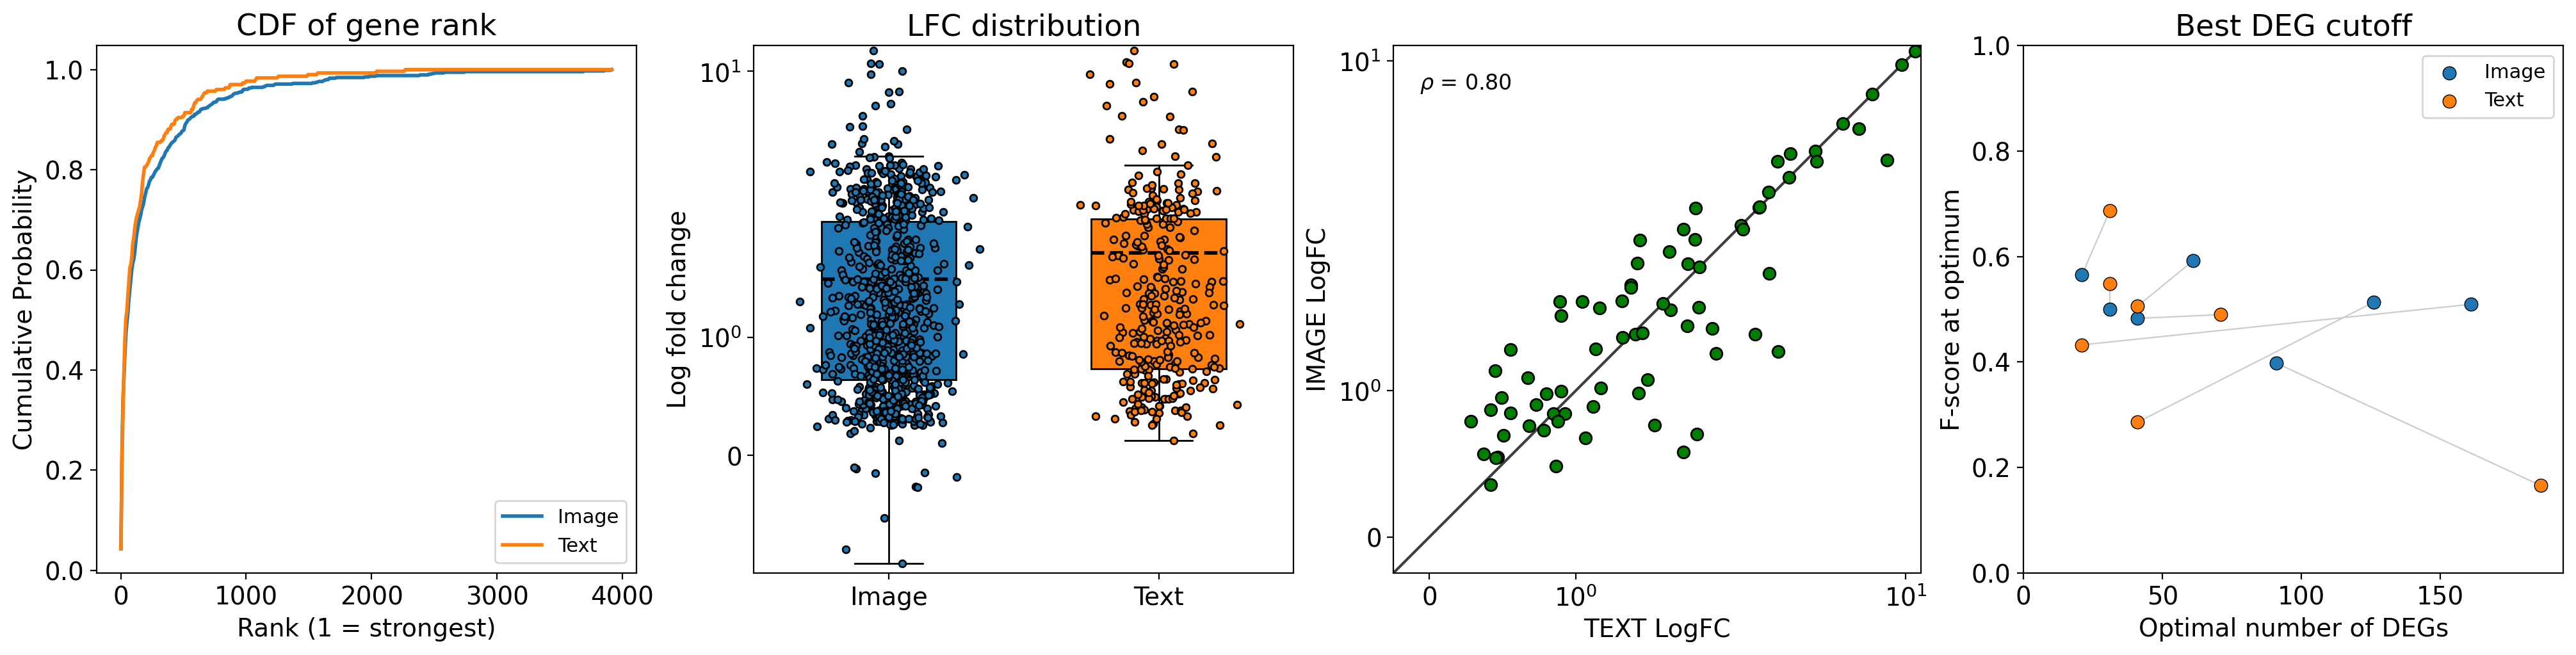

Spearman rho=0.80, p=1.16e-17, n=74 cell types
Mean optimal N:  image=76, text=60
Mean peak F:     image=0.51, text=0.44


In [51]:
import numpy as np

def ECDF(values):
    values = np.sort(np.asarray(values, dtype=float))
    def evaluate(x):
        return np.searchsorted(values, x, side="right") / len(values)
    return evaluate
from scipy.stats import spearmanr

img_color = "#1f77b4"
txt_color = "#ff7f0e"

with plt.rc_context({"font.size": 14}):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)

    # ============================================================
    # Col 1: Combined CDF — discussed only, image + text
    # ============================================================
    ax = axes[0]
    dr_img = data.query("discussed & modality == 'image'")["metrics_rank"].dropna()
    dr_txt = data.query("discussed & modality == 'text'")["metrics_rank"].dropna()
    x_vals = np.linspace(1, max(dr_img.max(), dr_txt.max()), 500)
    ax.plot(x_vals, ECDF(dr_img)(x_vals), color=img_color, linewidth=2, label="Image")
    ax.plot(x_vals, ECDF(dr_txt)(x_vals), color=txt_color, linewidth=2, label="Text")
    ax.set(xlabel="Rank (1 = strongest)", ylabel="Cumulative Probability",
           title="CDF of gene rank")
    ax.legend(fontsize=11)

    # ============================================================
    # Col 2: LFC boxplot — discussed only, image + text
    # ============================================================
    ax = axes[1]
    x_img = data.query("discussed & modality == 'image'")["metrics_logfc"].dropna().values
    x_txt = data.query("discussed & modality == 'text'")["metrics_logfc"].dropna().values
    bp = ax.boxplot([x_img, x_txt], positions=[1, 2], widths=0.5,
                    patch_artist=True, medianprops={"visible": False},
                    showfliers=False, showmeans=True, meanline=True,
                    meanprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor(img_color)
    bp["boxes"][1].set_facecolor(txt_color)
    for j, (vals, fc) in enumerate([(x_img, img_color), (x_txt, txt_color)]):
        xx = np.random.normal(j + 1, 0.1, size=len(vals))
        ax.scatter(xx, vals, edgecolor="k", facecolor=fc, zorder=10, s=15)
    ax.set(xticks=[1, 2], xticklabels=["Image", "Text"],
           ylabel="Log fold change", yscale="symlog", title="LFC distribution")
    ax.set_ylim(-1)

    # ============================================================
    # Col 3: LogFC scatter — TEXT vs IMAGE
    # ============================================================
    ax = axes[2]
    x = txt_mean[common_idx]
    y = img_mean[common_idx]
    ax.scatter(x, y, color="green", edgecolor="k", s=45, zorder=5)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(xlabel="TEXT LogFC", ylabel="IMAGE LogFC",
           xscale="symlog", yscale="symlog",
           aspect="equal", xlim=lims, ylim=lims)
    rho, pval = spearmanr(x, y)
    ax.text(0.05, 0.95, f"$\\rho$ = {rho:.2f}", transform=ax.transAxes,
            fontsize=12, verticalalignment="top")

    # ============================================================
    # Col 4: Best DEG cutoff and F-score
    # ============================================================
    ax = axes[3]

    shared_ds = sorted(set(img["dataset"]) & set(txt["dataset"]))
    for ds in shared_ds:
        img_row = img[img["dataset"] == ds].iloc[0]
        txt_row = txt[txt["dataset"] == ds].iloc[0]
        ax.plot([img_row["opt_n"], txt_row["opt_n"]],
                [img_row["opt_f"], txt_row["opt_f"]],
                color="0.8", linewidth=0.8, zorder=1)

    ax.scatter(img["opt_n"], img["opt_f"], color=img_color, edgecolor="k",
               linewidth=0.5, s=55, label="Image", zorder=5)
    ax.scatter(txt["opt_n"], txt["opt_f"], color=txt_color, edgecolor="k",
               linewidth=0.5, s=55, label="Text", zorder=6)
    ax.set(xlabel="Optimal number of DEGs", ylabel="F-score at optimum",
           xlim=(0, None), ylim=(0, 1), title="Best DEG cutoff")
    ax.legend(fontsize=11)

    import os
    os.makedirs("figures", exist_ok=True)
    fig.savefig("figures/fig_marker_selection.pdf", bbox_inches="tight")
    fig.savefig("figures/fig_marker_selection.png", bbox_inches="tight", dpi=300)
    plt.show()

    # Print summary stats
    print(f"Spearman rho={rho:.2f}, p={pval:.2e}, n={len(common_idx)} cell types")
    print(f"Mean optimal N:  image={img.opt_n.mean():.0f}, text={txt.opt_n.mean():.0f}")
    print(f"Mean peak F:     image={img.opt_f.mean():.2f}, text={txt.opt_f.mean():.2f}")

## Figure 1: Hildreth dataset detail

Dataset-specific figure showing discussed vs non-discussed markers for adipose_Hildreth2021.
4 rows: rank boxplots + CDFs, IMAGE LFC per cell type, TEXT LFC per cell type, PR curves + F-score.

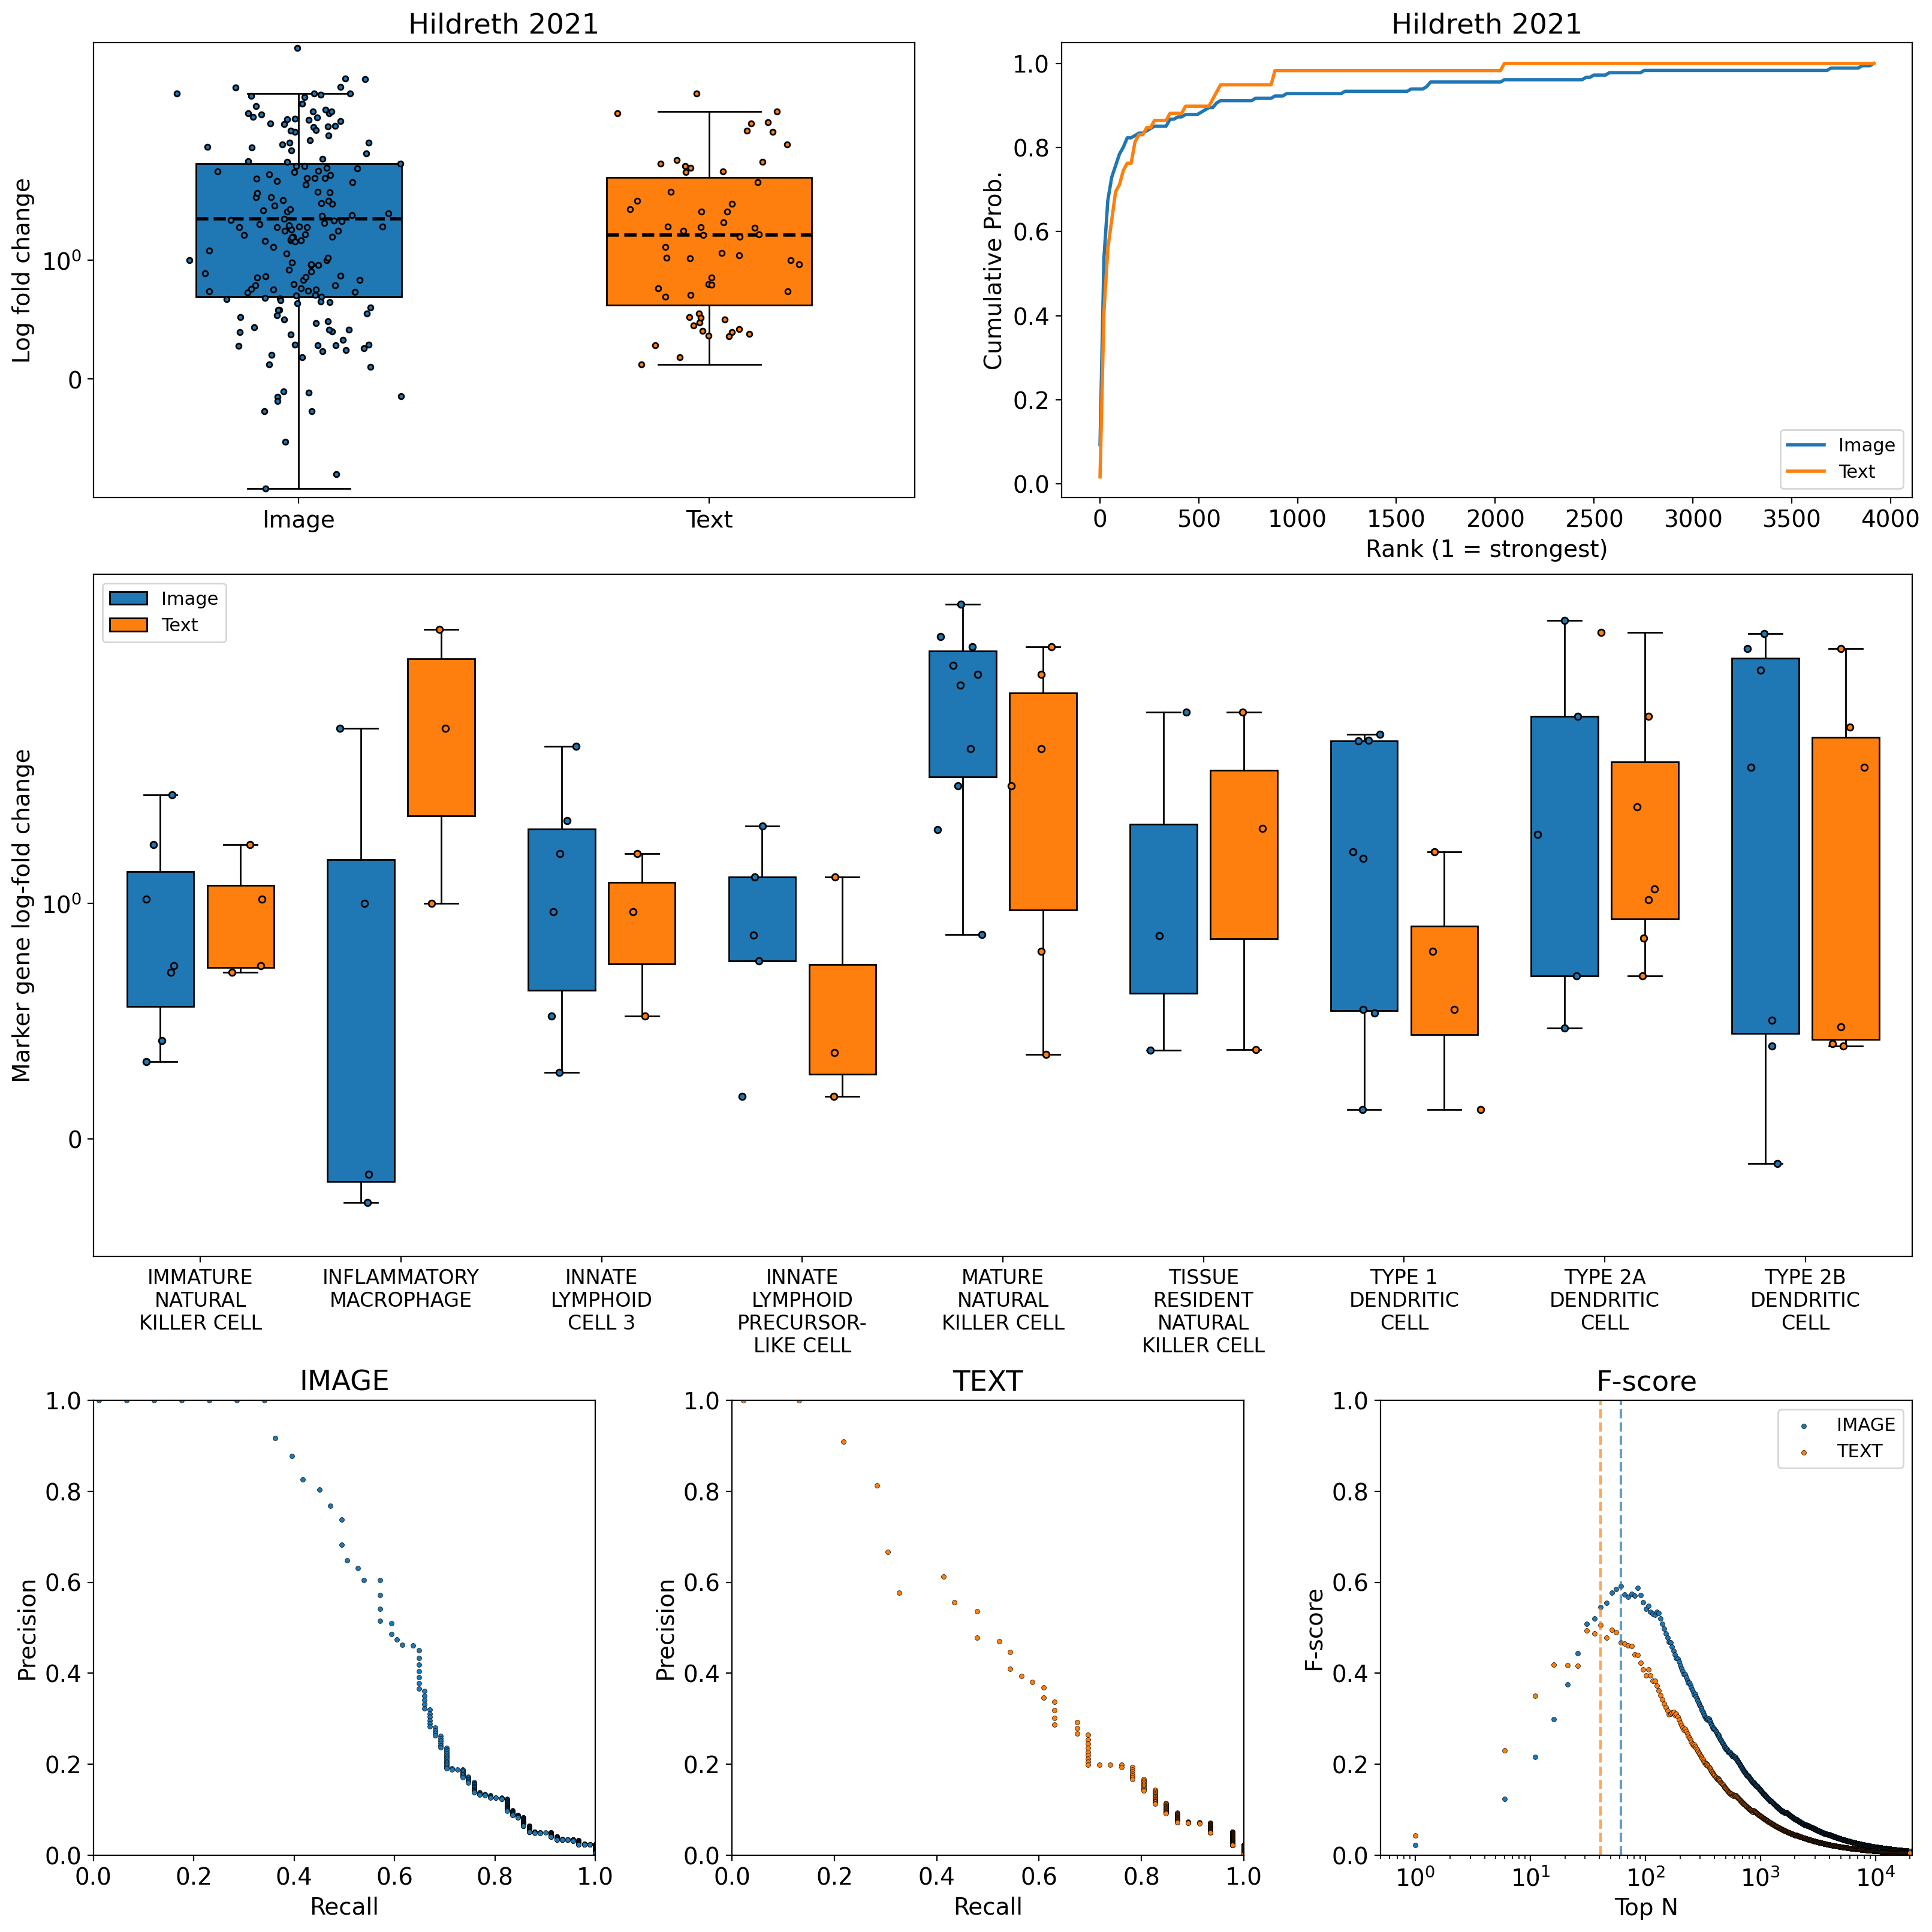

Saved: figures/fig_hildreth_detail.pdf


In [52]:
import matplotlib.gridspec as gridspec
import numpy as np

def ECDF(values):
    values = np.sort(np.asarray(values, dtype=float))
    def evaluate(x):
        return np.searchsorted(values, x, side="right") / len(values)
    return evaluate
from matplotlib.patches import Patch

ds = "adipose_Hildreth2021"
ds_short = "Hildreth 2021"

# Colors
img_color = "#1f77b4"
txt_color = "#ff7f0e"

with plt.rc_context({"font.size": 14}):

    df_h = data.query(f"dataset == '{ds}'")

    # PR curves for Hildreth
    h_row = agg[agg["ds_name"] == ds].iloc[0]
    curve_img = h_row["curve_image"]
    curve_txt = h_row["curve_text"]

    # Per-celltype LFC data (discussed only)
    img_d = ctplot["image"].xs(True, level="discussed").reindex(comm_ct)
    txt_d = ctplot["text"].xs(True, level="discussed").reindex(comm_ct)
    ct_labels = list(comm_ct)

    # ============================================================
    # Figure layout: 3 rows — top summary, per-celltype, PR curves
    # ============================================================
    fig = plt.figure(figsize=(16, 16), constrained_layout=True)
    gs = fig.add_gridspec(3, 12, height_ratios=[1, 1.5, 1])

    # ============================================================
    # Row 1: LFC boxplot (image + text) | Rank CDF (image + text)
    # ============================================================

    # (a) LFC boxplot — discussed markers only, image vs text
    ax = fig.add_subplot(gs[0, 0:6])
    x_img = df_h.query("discussed & modality == 'image'")["metrics_logfc"].dropna().values
    x_txt = df_h.query("discussed & modality == 'text'")["metrics_logfc"].dropna().values
    bp = ax.boxplot([x_img, x_txt], positions=[1, 2], widths=0.5, patch_artist=True,
                    medianprops={"visible": False}, showfliers=False,
                    showmeans=True, meanline=True,
                    meanprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor(img_color)
    bp["boxes"][1].set_facecolor(txt_color)
    for j, (vals, fc) in enumerate([(x_img, img_color), (x_txt, txt_color)]):
        xx = np.random.normal(j + 1, 0.1, size=len(vals))
        ax.scatter(xx, vals, edgecolor="k", facecolor=fc, zorder=10, s=10)
    ax.set(xticks=[1, 2], xticklabels=["Image", "Text"],
           ylabel="Log fold change", yscale="symlog", title=f"{ds_short}")
    ax.set_ylim(-1)

    # (b) CDF — discussed markers only, image vs text
    ax = fig.add_subplot(gs[0, 6:12])
    dr_img = df_h.query("discussed & modality == 'image'")["metrics_rank"].dropna()
    dr_txt = df_h.query("discussed & modality == 'text'")["metrics_rank"].dropna()
    x_max = max(dr_img.max(), dr_txt.max())
    x_vals = np.linspace(1, x_max, 200)
    ax.plot(x_vals, ECDF(dr_img)(x_vals), color=img_color, linewidth=2, label="Image")
    ax.plot(x_vals, ECDF(dr_txt)(x_vals), color=txt_color, linewidth=2, label="Text")
    ax.set(xlabel="Rank (1 = strongest)", ylabel="Cumulative Prob.",
           title=f"{ds_short}")
    ax.legend(fontsize=11)

    # ============================================================
    # Row 2: Per-cell-type LFC — image (blue) + text (orange), discussed only
    # ============================================================
    ax_ct = fig.add_subplot(gs[1, :])
    dist_bw = 1.5
    space = 0.3
    ct_idx = np.arange(len(ct_labels)) * dist_bw

    ax_ct.boxplot(list(img_d.values), positions=ct_idx - space, widths=0.5,
                  patch_artist=True, medianprops={"visible": False}, showfliers=False,
                  boxprops=dict(facecolor=img_color))
    ax_ct.boxplot(list(txt_d.values), positions=ct_idx + space, widths=0.5,
                  patch_artist=True, medianprops={"visible": False}, showfliers=False,
                  boxprops=dict(facecolor=txt_color))
    for k, (iv, tv) in enumerate(zip(img_d.values, txt_d.values)):
        ax_ct.scatter(np.random.normal(ct_idx[k] - space, 0.1, len(iv)), iv,
                      edgecolor="k", facecolor=img_color, zorder=10, s=15)
        ax_ct.scatter(np.random.normal(ct_idx[k] + space, 0.1, len(tv)), tv,
                      edgecolor="k", facecolor=txt_color, zorder=10, s=15)

    ax_ct.legend(handles=[Patch(facecolor=img_color, edgecolor="k", label="Image"),
                          Patch(facecolor=txt_color, edgecolor="k", label="Text")],
                 fontsize=11)
    ax_ct.set(ylabel="Marker gene log-fold change", yscale="symlog", ylim=(-0.5, None))
    ax_ct.set_xticks(ct_idx)
    wrapped = wrap_labels(ct_labels, width=12)
    ax_ct.set_xticklabels(wrapped, rotation=0, ha="center", fontsize=12)

    # ============================================================
    # Row 3: PR curves + F-score
    # ============================================================

    # PR curve — IMAGE
    ax = fig.add_subplot(gs[2, 0:4])
    ax.scatter(curve_img[:, 2], curve_img[:, 1], color=img_color, edgecolor="k",
               linewidth=0.25, s=8)
    ax.set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1),
           title="IMAGE")

    # PR curve — TEXT
    ax = fig.add_subplot(gs[2, 4:8])
    ax.scatter(curve_txt[:, 2], curve_txt[:, 1], color=txt_color, edgecolor="k",
               linewidth=0.25, s=8)
    ax.set(xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1),
           title="TEXT")

    # F-score vs top-N
    ax = fig.add_subplot(gs[2, 8:12])
    for curve, color, label in [(curve_img, img_color, "IMAGE"),
                                  (curve_txt, txt_color, "TEXT")]:
        n_vals = curve[:, 0]
        f_vals = curve[:, 3]
        mask = f_vals > 0
        ax.scatter(n_vals[mask], f_vals[mask], color=color, edgecolor="k",
                   linewidth=0.25, s=8, label=label)
        if mask.any():
            best_idx = np.argmax(f_vals[mask])
            ax.axvline(n_vals[mask][best_idx], linestyle="--", color=color, alpha=0.7)
    ax.set(xlabel="Top N", ylabel="F-score", xlim=(0.5, None), ylim=(0, 1),
           xscale="log", title="F-score")
    ax.legend(fontsize=11)

    import os
    os.makedirs("figures", exist_ok=True)
    fig.savefig("figures/fig_hildreth_detail.pdf", bbox_inches="tight")
    plt.show()
    print("Saved: figures/fig_hildreth_detail.pdf")